

### Análise descritiva dados de exportação e comercialização de vinhos dos últimos 15 anos
##### Fonte: ComexStat - Ministério da Economia do Brasil - https://comexstat.mdic.gov.br/pt/home

In [2]:
import pandas as pd
from pathlib import Path

# Caminho do arquivo
file_path = Path(r"C:/Users/GUTO-GAMER/Desktop/FIAP/Database/dados_comercio_exterior/V_EXPORTACAO_GERAL_2009-01_2024-12_DT20251016.csv")

# Leitura robusta
df = pd.read_csv(
    file_path,
    sep=';', 
    encoding='utf-8-sig',
    engine='c',
    on_bad_lines='skip',
    decimal=',',
    thousands='.'
)

# Normalizar nomes de colunas (remover quebras, espaços, etc.)
# Normalizar nomes de colunas
df.columns = df.columns.str.replace(r'[\r\n\t"]', '', regex=True).str.strip()

# Remover \r, \n e espaços extras das células de texto
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.replace('\r', '', regex=False).str.replace('\n', '', regex=False).str.strip()


# Padronizar nomes para facilitar acesso
rename_map = {
    'Ano': 'ANO',
    'Mês': 'MES',
    'Países': 'PAISES',
    'UF do Produto': 'UF_PRODUTO',
    'Código NCM': 'CODIGO_NCM',
    'Descrição NCM': 'DESCRICAO_NCM',
    'Unidade estatística': 'UNIDADE_ESTATISTICA',
    'Valor US$ FOB': 'VALOR_FOB_USD',
    'Quilograma Líquido': 'KG_LIQUIDO',
    'Quantidade Estatística': 'QT_ESTATISTICA'
}
df = df.rename(columns=lambda c: rename_map.get(c, c))

# Selecionar apenas as colunas desejadas
cols_desejadas = [
    'ANO', 'MES', 'PAISES', 'UF_PRODUTO',
    'CODIGO_NCM', 'DESCRICAO_NCM', 'UNIDADE_ESTATISTICA',
    'VALOR_FOB_USD', 'KG_LIQUIDO', 'QT_ESTATISTICA'
]

df_principal = df[cols_desejadas].copy()

# Exibir as primeiras linhas de forma mais legível
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
display(df_principal.head(15))


,ANO,MES,PAISES,UF_PRODUTO,CODIGO_NCM,DESCRICAO_NCM,UNIDADE_ESTATISTICA,VALOR_FOB_USD,KG_LIQUIDO,QT_ESTATISTICA
0,2024,12. Dezembro,Alemanha,Rio Grande do Sul,22041010,"Vinhos espumantes e vinhos espumosos, tipo cha...",LITRO,33762,10692,10692
1,2024,12. Dezembro,Alemanha,São Paulo,22042100,"Outros vinhos, mostos de uvas, fermentados, im...",LITRO,61,18,18
2,2024,12. Dezembro,Antígua e Barbuda,Rio Grande do Sul,22041090,"Outros vinhos de uvas frescas, espumantes e es...",LITRO,17,10,10
3,2024,12. Dezembro,Antígua e Barbuda,Rio Grande do Sul,22042100,"Outros vinhos, mostos de uvas, fermentados, im...",LITRO,6,2,2
4,2024,12. Dezembro,Antígua e Barbuda,Rio de Janeiro,22042100,"Outros vinhos, mostos de uvas, fermentados, im...",LITRO,116,20,23
5,2024,12. Dezembro,Antígua e Barbuda,São Paulo,22042100,"Outros vinhos, mostos de uvas, fermentados, im...",LITRO,23,8,8
6,2024,12. Dezembro,Antígua e Barbuda,São Paulo,22043000,Outros mostos de uvas,LITRO,78,32,32
7,2024,12. Dezembro,Bahamas,Pará,22042100,"Outros vinhos, mostos de uvas, fermentados, im...",LITRO,37,9,9
8,2024,12. Dezembro,Bahamas,Pernambuco,22042100,"Outros vinhos, mostos de uvas, fermentados, im...",LITRO,33,11,9
9,2024,12. Dezembro,Bahamas,Pernambuco,22042211,Vinhos em recipientes de capacidade não superi...,LITRO,354,124,100


### Verificação de linhas preenchidas com zero

In [3]:

# Verificar se todas as colunas numéricas em uma linha são zero
paises_com_zeros_em_todas_colunas = df_principal[
    (df_principal == 0).all(axis=1)
]

# Exibir o nome dos países que se encaixam nesse critério
if not paises_com_zeros_em_todas_colunas.empty:
    print("Países com valor zero em todas as colunas numéricas:")
    display(paises_com_zeros_em_todas_colunas['País'])
else:
    print("Não há países com valor zero em todas as colunas numéricas.")

Não há países com valor zero em todas as colunas numéricas.


#### CONSOLIDAR por ANO + PAIS + UF 

In [4]:
import pandas as pd

# --- 0) Higienização rápida: garantir numéricos
for col in ['VALOR_FOB_USD', 'KG_LIQUIDO']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# --- 1) Ver quais anos existem (para você validar que não é só 2009)
anos_disponiveis = sorted(pd.Series(df['ANO'].unique()).dropna().tolist())
print("Anos no dataset:", anos_disponiveis)

# --- 2) Chaves do agrupamento "base"
chaves = ['ANO', 'PAISES', 'UF_PRODUTO']
# Se quiser incluir a descrição do NCM quando existir, ADICIONE (seu código estava mantendo igual)
if 'DESCRICAO_NCM' in df.columns:
    chaves = chaves + ['DESCRICAO_NCM']

# --- 3) Consolidado por ANO, País, UF (e NCM opcional) - bom para pivot e séries históricas
df_consolidado_ncm = (
    df.groupby(chaves, dropna=False, as_index=False)
      .agg(
          Exportacao_FOB_USD=('VALOR_FOB_USD', 'sum'),
          Exportacao_KG=('KG_LIQUIDO', 'sum')
      )
)

display(df_consolidado_ncm.sort_values(['ANO'] + [c for c in chaves if c != 'ANO'], ascending=[False] + [True]*(len(chaves)-1)).head(15))

# --- 4) Versão 'wide' com ANO nas colunas (opcional)
df_wide_ncm = (
    df_consolidado_ncm
      .pivot_table(
          index=[c for c in chaves if c != 'ANO'],
          columns='ANO',
          values=['Exportacao_FOB_USD','Exportacao_KG'],
          aggfunc='sum',
          fill_value=0
      )
      .sort_index()
)

# --- 5) Consolidação SEM ANO (somando o período inteiro) para ranking geral
#     -> Aqui tiramos 'ANO' das chaves para não enviesar por ano
chaves_sem_ano = [c for c in chaves if c != 'ANO']

df_consolidado_total = (
    df.groupby(chaves_sem_ano, dropna=False, as_index=False)
      .agg(
          Exportacao_FOB_USD=('VALOR_FOB_USD', 'sum'),
          Exportacao_KG=('KG_LIQUIDO', 'sum')
      )
)

# --- 6) País que mais exportou no período (critério: FOB; mude para KG se preferir)
df_pais_total = (
    df_consolidado_total
      .groupby('PAISES', as_index=False)
      .agg(
          Exportacao_FOB_USD=('Exportacao_FOB_USD', 'sum'),
          Exportacao_KG=('Exportacao_KG', 'sum')
      )
      .sort_values('Exportacao_FOB_USD', ascending=False)
)

top_pais = df_pais_total.iloc[0]['PAISES']
top_pais_fob = df_pais_total.iloc[0]['Exportacao_FOB_USD']
top_pais_kg = df_pais_total.iloc[0]['Exportacao_KG']

print(f"\nPaís com MAIOR exportação no período: {top_pais}")
print(f" - Total FOB (USD): {top_pais_fob:,.2f}")
print(f" - Total KG: {top_pais_kg:,.0f}")

# --- 7) Dentro do país líder, qual UF mais exportou para ele
df_top_pais_ufs = (
    df_consolidado_total[df_consolidado_total['PAISES'] == top_pais]
      .groupby('UF_PRODUTO', as_index=False)
      .agg(
          Exportacao_FOB_USD=('Exportacao_FOB_USD', 'sum'),
          Exportacao_KG=('Exportacao_KG', 'sum')
      )
      .sort_values('Exportacao_FOB_USD', ascending=False)
)

top_uf = df_top_pais_ufs.iloc[0]['UF_PRODUTO']
top_uf_fob = df_top_pais_ufs.iloc[0]['Exportacao_FOB_USD']
top_uf_kg = df_top_pais_ufs.iloc[0]['Exportacao_KG']

print(f"\nUF que mais exportou para {top_pais}: {top_uf}")
print(f" - Total FOB (USD): {top_uf_fob:,.2f}")
print(f" - Total KG: {top_uf_kg:,.0f}")

# (Opcional) ver top 3 UFs para o país líder
print("\nTop 10 UFs para o país líder (por FOB/US):")
display(df_top_pais_ufs.head(10))


Anos no dataset: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,ANO,PAISES,UF_PRODUTO,DESCRICAO_NCM,Exportacao_FOB_USD,Exportacao_KG
4472,2024,Alemanha,Não Declarada,"Outros vinhos de uvas frescas, espumantes e es...",49,23
4473,2024,Alemanha,Não Declarada,"Outros vinhos, mostos de uvas, fermentados, im...",3357,128
4474,2024,Alemanha,Não Declarada,"Vinhos espumantes e vinhos espumosos, tipo cha...",1240,139
4475,2024,Alemanha,Pará,"Outros vermutes e vinhos de uvas frescas, arom...",25,6
4476,2024,Alemanha,Rio Grande do Sul,"Outros vinhos de uvas frescas, espumantes e es...",5445,728
4477,2024,Alemanha,Rio Grande do Sul,"Outros vinhos, mostos de uvas, fermentados, im...",38648,6055
4478,2024,Alemanha,Rio Grande do Sul,"Vinhos espumantes e vinhos espumosos, tipo cha...",71203,21609
4479,2024,Alemanha,Rio de Janeiro,"Vinhos espumantes e vinhos espumosos, tipo cha...",44,43
4480,2024,Alemanha,Santa Catarina,"Outros vinhos, mostos de uvas, fermentados, im...",419,45
4481,2024,Alemanha,São Paulo,"Outros vinhos, mostos de uvas, fermentados, im...",5671,438



País com MAIOR exportação no período: Paraguai
 - Total FOB (USD): 50,455,423.00
 - Total KG: 35,217,736

UF que mais exportou para Paraguai: Rio Grande do Sul
 - Total FOB (USD): 45,094,380.00
 - Total KG: 31,326,527

Top 10 UFs para o país líder (por FOB/US):


,UF_PRODUTO,Exportacao_FOB_USD,Exportacao_KG
6,Rio Grande do Sul,45094380,31326527
5,Paraná,3313133,2474026
8,São Paulo,1526609,1011020
7,Santa Catarina,376436,364103
0,Bahia,65331,22160
4,Não Declarada,27146,13872
1,Espírito Santo,26180,3927
9,Zona Não Declarada,21318,658
3,Minas Gerais,3380,643
2,Mato Grosso do Sul,1510,800


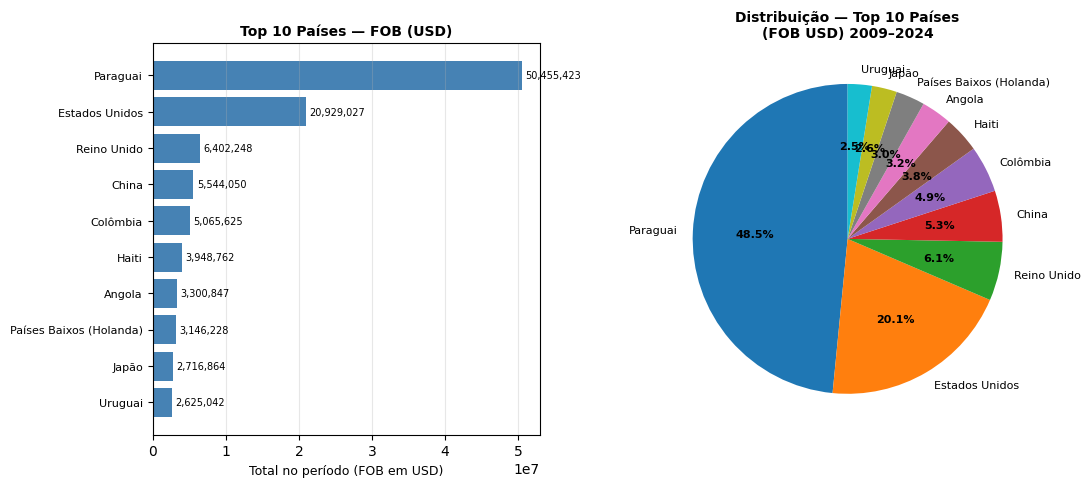

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 0) (Opcional) Filtrar ANOS antes de agregar
ano_ini, ano_fim = 2009, 2024
df_base = df.copy()
df_base['ANO'] = pd.to_numeric(df_base['ANO'], errors='coerce')
df_base = df_base[(df_base['ANO'] >= ano_ini) & (df_base['ANO'] <= ano_fim)]

# Sanitizar numéricos
for col in ['VALOR_FOB_USD', 'KG_LIQUIDO']:
    if col in df_base.columns:
        df_base[col] = pd.to_numeric(df_base[col], errors='coerce')

# ================================

df_paises_metricas = (
    df_base.groupby('PAISES', dropna=False, as_index=False)
           .agg(Exportacao_FOB_USD=('VALOR_FOB_USD', 'sum'),
                Exportacao_KG=('KG_LIQUIDO', 'sum'))
)

# Escolha a métrica do gráfico (FOB é padrão; troque para 'Exportacao_KG' se quiser volume)
metrica = 'Exportacao_FOB_USD'

# ================================
# 2) Top 10 por FOB (ou KG) — base para ambos os gráficos
top_10 = df_paises_metricas.sort_values(metrica, ascending=False).head(10)
top_10_invertido = top_10.iloc[::-1]  # para barras com maior no topo visualmente

# ================================
# 3) Criar subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))  # <-- define layout horizontal

# --- Gráfico de barras horizontais ---
ax1.barh(range(len(top_10_invertido)), top_10_invertido[metrica], color='steelblue')
ax1.set_yticks(range(len(top_10_invertido)))
ax1.set_yticklabels(top_10_invertido['PAISES'], fontsize=8)
ax1.set_xlabel('Total no período (FOB em USD)' if metrica == 'Exportacao_FOB_USD' else 'Total no período (KG)', fontsize=9)
ax1.set_title(f'Top 10 Países — {("FOB (USD)" if metrica=="Exportacao_FOB_USD" else "KG")}', fontsize=10, fontweight='bold')

# Anotar valores nas barras
max_val = top_10_invertido[metrica].max() if len(top_10_invertido) else 0
for i, v in enumerate(top_10_invertido[metrica]):
    ax1.text(v + max_val*0.01, i, f'{v:,.0f}', va='center', fontsize=7)

ax1.grid(True, axis='x', alpha=0.3)

# --- Gráfico de pizza ---
labels = list(top_10['PAISES'])
sizes = list(top_10[metrica])

wedges, texts, autotexts = ax2.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 8}
)
ax2.set_title(f'Distribuição — Top 10 Países\n({("FOB USD" if metrica=="Exportacao_FOB_USD" else "KG")}) {ano_ini}–{ano_fim}',
              fontsize=10, fontweight='bold')

for a in autotexts:
    a.set_fontweight('bold')
    a.set_fontsize(8)

# --- Ajustes finais ---
plt.tight_layout(w_pad=3.5) 
plt.show()


###  Média anual de exportação (FOB USD)


📊 Média anual de exportação (FOB USD):


,ANO,Media_FOB_USD
0,2009,13893.842742
1,2010,17382.129921
2,2011,15915.724771
3,2012,17282.884615
4,2013,18964.768489
5,2014,30754.293413
6,2015,18054.995708
7,2016,25089.072340
8,2017,30697.816054
9,2018,11429.935323


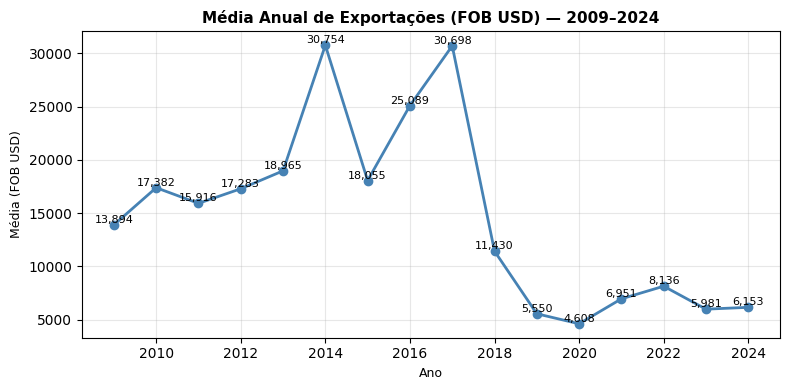

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 0) Filtrar ANOS antes de agregar
ano_ini, ano_fim = 2009, 2024
df_base = df.copy()
df_base['ANO'] = pd.to_numeric(df_base['ANO'], errors='coerce')
df_base = df_base[(df_base['ANO'] >= ano_ini) & (df_base['ANO'] <= ano_fim)]

# Garantir tipo numérico em FOB
df_base['VALOR_FOB_USD'] = pd.to_numeric(df_base['VALOR_FOB_USD'], errors='coerce')

# ================================
# 1) Calcular a média anual de exportação
df_media_ano = (
    df_base.groupby('ANO', as_index=False)
           .agg(Media_FOB_USD=('VALOR_FOB_USD', 'mean'))
           .sort_values('ANO')
)

print("\n📊 Média anual de exportação (FOB USD):")
display(df_media_ano)

# ================================
# 2) Gráfico da média de exportação
plt.figure(figsize=(8, 4))
plt.plot(df_media_ano['ANO'], df_media_ano['Media_FOB_USD'],
         marker='o', color='steelblue', linewidth=2)

plt.title(f'Média Anual de Exportações (FOB USD) — {ano_ini}–{ano_fim}',
          fontsize=11, fontweight='bold')
plt.xlabel('Ano', fontsize=9)
plt.ylabel('Média (FOB USD)', fontsize=9)
plt.grid(True, alpha=0.3)

# Adicionar rótulos de valor nos pontos
for i, v in enumerate(df_media_ano['Media_FOB_USD']):
    plt.text(df_media_ano['ANO'].iloc[i], v, f'{v:,.0f}',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


### Média anual de exportação (em litros) — 2009 a 2024


Média anual de exportação (em litros) — 2009 a 2024:


,ANO,Media_Litros
0,2009,6225.649194
1,2010,35983.405512
2,2011,4192.226300
3,2012,5193.826923
4,2013,5174.710611
5,2014,7988.044910
6,2015,6239.570815
7,2016,9043.123404
8,2017,11646.531773
9,2018,5501.684080


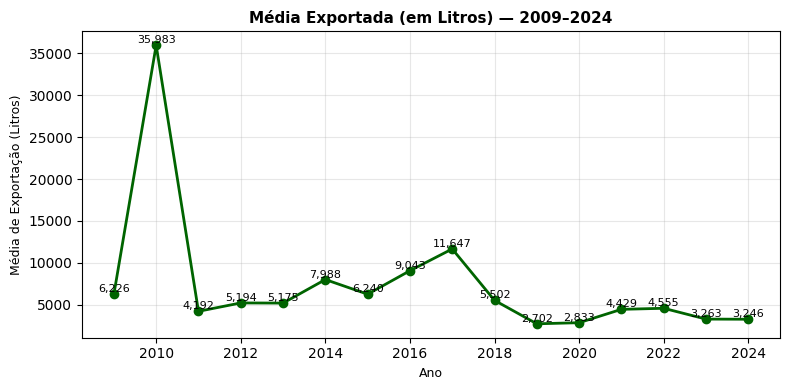

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 0) Detectar e preparar coluna de litros
if 'LITROS' in df.columns:
    col_litros = 'LITROS'
elif 'QT_ESTATISTICA' in df.columns:
    col_litros = 'QT_ESTATISTICA'
else:
    raise ValueError("Nenhuma coluna de volume encontrada ('LITROS' ou 'QT_ESTATISTICA').")

# ================================
# 1) Definir período fixo (últimos 15 anos completos da base)
ano_ini, ano_fim = 2009, 2024

df_base = df.copy()
df_base['ANO'] = pd.to_numeric(df_base['ANO'], errors='coerce')
df_base[col_litros] = pd.to_numeric(df_base[col_litros], errors='coerce')

# Filtrar o intervalo desejado
df_filtrado = df_base[(df_base['ANO'] >= ano_ini) & (df_base['ANO'] <= ano_fim)]

# ================================
# 2) Calcular média anual de exportação (em litros)
df_media_ano = (
    df_filtrado.groupby('ANO', as_index=False)
               .agg(Media_Litros=(col_litros, 'mean'))
               .sort_values('ANO')
)

print(f"\nMédia anual de exportação (em litros) — {ano_ini} a {ano_fim}:")
display(df_media_ano)

# ================================
# 3) Gerar gráfico de linha
plt.figure(figsize=(8, 4))
plt.plot(df_media_ano['ANO'], df_media_ano['Media_Litros'],
         marker='o', color='darkgreen', linewidth=2)

plt.title(f'Média Exportada (em Litros) — {ano_ini}–{ano_fim}',
          fontsize=11, fontweight='bold')
plt.xlabel('Ano', fontsize=9)
plt.ylabel('Média de Exportação (Litros)', fontsize=9)
plt.grid(True, alpha=0.3)

# Adicionar rótulos nos pontos
for i, v in enumerate(df_media_ano['Media_Litros']):
    plt.text(df_media_ano['ANO'].iloc[i], v, f'{v:,.0f}',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


### Correlação entre volume exportado (litros) e valor FOB (USD) — 2009 a 2024:


Correlação entre volume exportado (litros) e valor FOB (USD) — 2009 a 2024:


,ANO,Correlacao_Litros_FOB
0,2009,0.762340
1,2010,0.012020
2,2011,0.572785
3,2012,0.669961
4,2013,0.775799
5,2014,0.876604
6,2015,0.744146
7,2016,0.933077
8,2017,0.729246
9,2018,0.990832


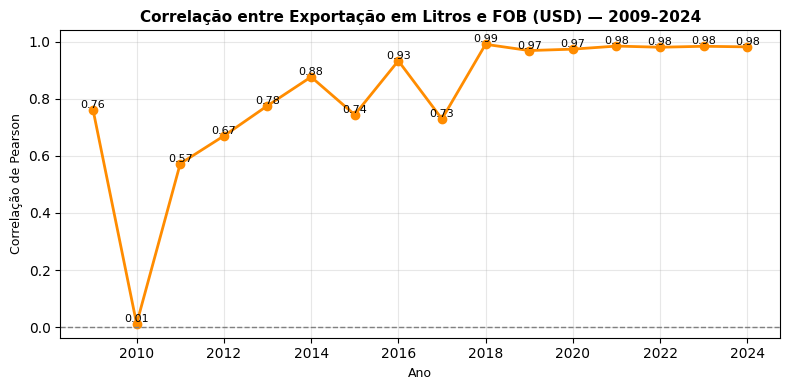

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 0) Detectar colunas principais
if 'LITROS' in df.columns:
    col_litros = 'LITROS'
elif 'QT_ESTATISTICA' in df.columns:
    col_litros = 'QT_ESTATISTICA'
else:
    raise ValueError("Nenhuma coluna de volume encontrada ('LITROS' ou 'QT_ESTATISTICA').")

if 'VALOR_FOB_USD' not in df.columns:
    raise ValueError("A coluna 'VALOR_FOB_USD' não foi encontrada no DataFrame.")

# ================================
# 1) Filtrar anos consolidados (2009–2023)
ano_ini, ano_fim = 2009, 2024

df_base = df.copy()
df_base['ANO'] = pd.to_numeric(df_base['ANO'], errors='coerce')
df_base[col_litros] = pd.to_numeric(df_base[col_litros], errors='coerce')
df_base['VALOR_FOB_USD'] = pd.to_numeric(df_base['VALOR_FOB_USD'], errors='coerce')
df_filtrado = df_base[(df_base['ANO'] >= ano_ini) & (df_base['ANO'] <= ano_fim)]

# ================================
# 2) Calcular correlação ano a ano
correlacoes = []
for ano, grupo in df_filtrado.groupby('ANO'):
    if grupo[[col_litros, 'VALOR_FOB_USD']].dropna().shape[0] > 1:
        corr = grupo[col_litros].corr(grupo['VALOR_FOB_USD'])
        correlacoes.append({'ANO': ano, 'Correlacao_Litros_FOB': corr})
    else:
        correlacoes.append({'ANO': ano, 'Correlacao_Litros_FOB': None})

df_correlacao = pd.DataFrame(correlacoes).sort_values('ANO')

print(f"\nCorrelação entre volume exportado (litros) e valor FOB (USD) — {ano_ini} a {ano_fim}:")
display(df_correlacao)

# ================================
# 3) Gráfico da correlação por ano
plt.figure(figsize=(8, 4))
plt.plot(df_correlacao['ANO'], df_correlacao['Correlacao_Litros_FOB'],
         marker='o', color='darkorange', linewidth=2)

plt.title(f"Correlação entre Exportação em Litros e FOB (USD) — {ano_ini}–{ano_fim}",
          fontsize=11, fontweight='bold')
plt.xlabel('Ano', fontsize=9)
plt.ylabel('Correlação de Pearson', fontsize=9)
plt.grid(True, alpha=0.3)

# Linha de referência em y=0
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Rótulos nos pontos
for i, v in enumerate(df_correlacao['Correlacao_Litros_FOB']):
    if pd.notna(v):
        plt.text(df_correlacao['ANO'].iloc[i], v, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Mostra claramente quais países têm correlação alta ou baixa.

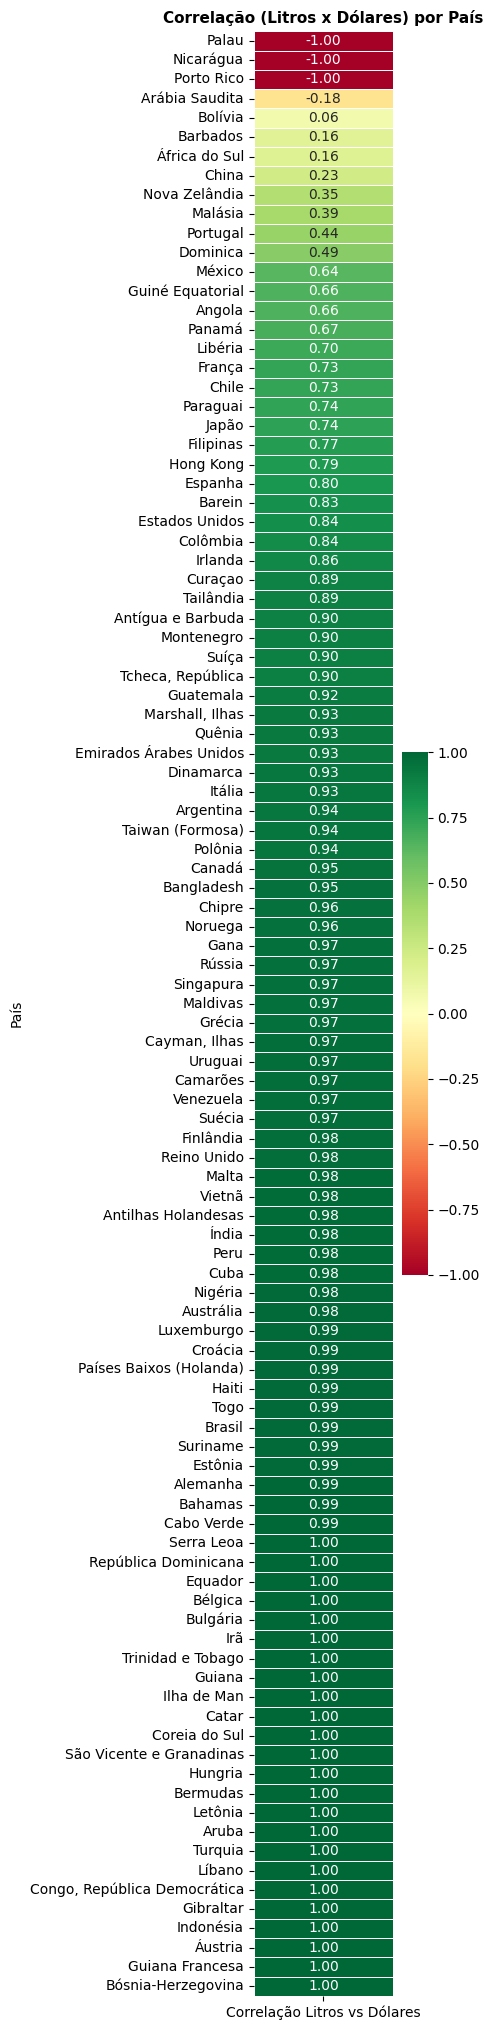

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Se df_pivotado não existir, tentar construí-lo a partir de df_principal ou df
if 'df_pivotado' not in globals():
    if 'df_principal' in globals():
        src = df_principal.copy()
    elif 'df' in globals():
        src = df.copy()
    else:
        raise NameError("Nenhum dos DataFrames 'df_pivotado', 'df_principal' ou 'df' está disponível no ambiente.")

    # Detectar coluna de volume disponível
    if 'QT_ESTATISTICA' in src.columns:
        vol_col = 'QT_ESTATISTICA'
    elif 'LITROS' in src.columns:
        vol_col = 'LITROS'
    elif 'KG_LIQUIDO' in src.columns:
        vol_col = 'KG_LIQUIDO'
    else:
        raise ValueError("Nenhuma coluna de volume encontrada ('QT_ESTATISTICA', 'LITROS' ou 'KG_LIQUIDO').")

    # Normalizar nomes e converter tipos
    tmp = src.rename(columns={'PAISES': 'País', 'VALOR_FOB_USD': 'dolares', vol_col: 'litros'})
    tmp['ANO'] = pd.to_numeric(tmp['ANO'], errors='coerce')
    tmp['litros'] = pd.to_numeric(tmp['litros'], errors='coerce')
    tmp['dolares'] = pd.to_numeric(tmp['dolares'], errors='coerce')
    tmp = tmp.dropna(subset=['País', 'ANO'])

    # Agregar por País e Ano somando litros e dólares (evita duplicidades)
    df_pivotado = (
        tmp.groupby(['País', 'ANO'], as_index=False)
           .agg(litros=('litros', 'sum'), dolares=('dolares', 'sum'))
    )

# --- Base segura: apenas colunas necessárias e numéricas
base = df_pivotado[['País','litros','dolares']].copy()
base['litros']  = pd.to_numeric(base['litros'],  errors='coerce')
base['dolares'] = pd.to_numeric(base['dolares'], errors='coerce')
base = base.dropna(subset=['País','litros','dolares'])

# --- Filtrar países com ao menos 2 pontos e variância > 0 nas duas séries
def _ok(g):
    g2 = g[['litros','dolares']].dropna()
    if len(g2) < 2:
        return False
    return (g2['litros'].std(ddof=0) > 0) and (g2['dolares'].std(ddof=0) > 0)

base_valid = base.groupby('País', group_keys=False).filter(_ok)

# --- Correlação por país (evita FutureWarning pois seleciona colunas explicitamente)
correlation_by_country = (
    base_valid
      .groupby('País')[['litros','dolares']]
      .apply(lambda g: g['litros'].corr(g['dolares']))
      .rename('Correlação Litros vs Dólares')
      .to_frame()
      .dropna()
      .sort_values('Correlação Litros vs Dólares', ascending=True)
)

# --- Heatmap (mesmo estilo do seu código)
plt.figure(figsize=(5, max(4, len(correlation_by_country) * 0.2)))  # altura dinâmica
sns.heatmap(
    correlation_by_country,
    annot=True, fmt=".2f", cmap='RdYlGn', linewidths=0.5, cbar=True,
    center=0, vmin=-1, vmax=1
)
plt.title('Correlação (Litros x Dólares) por País', fontsize=11, fontweight='bold')
plt.xlabel('')
plt.ylabel('País')
plt.tight_layout()
plt.show()


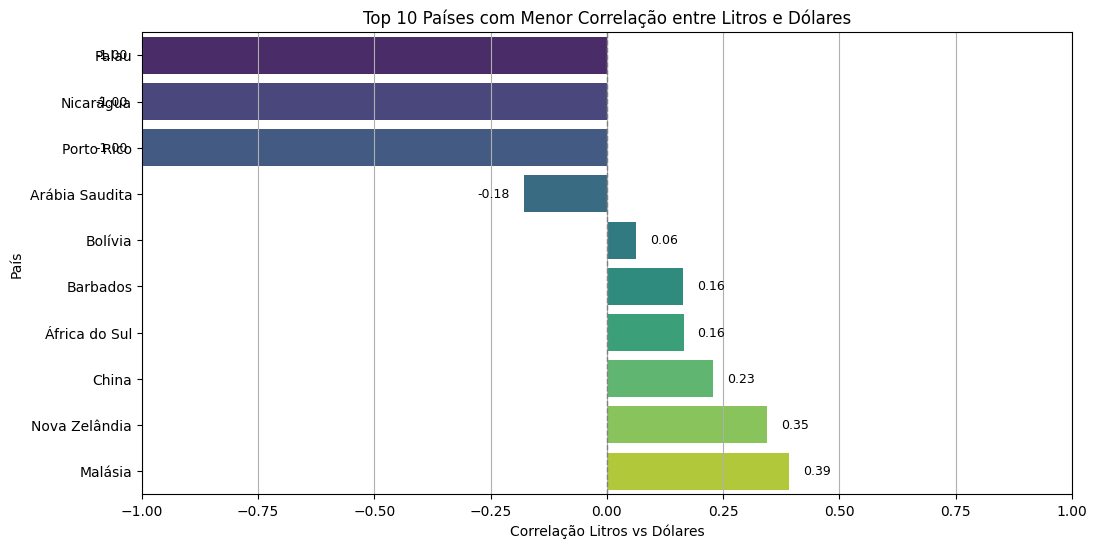

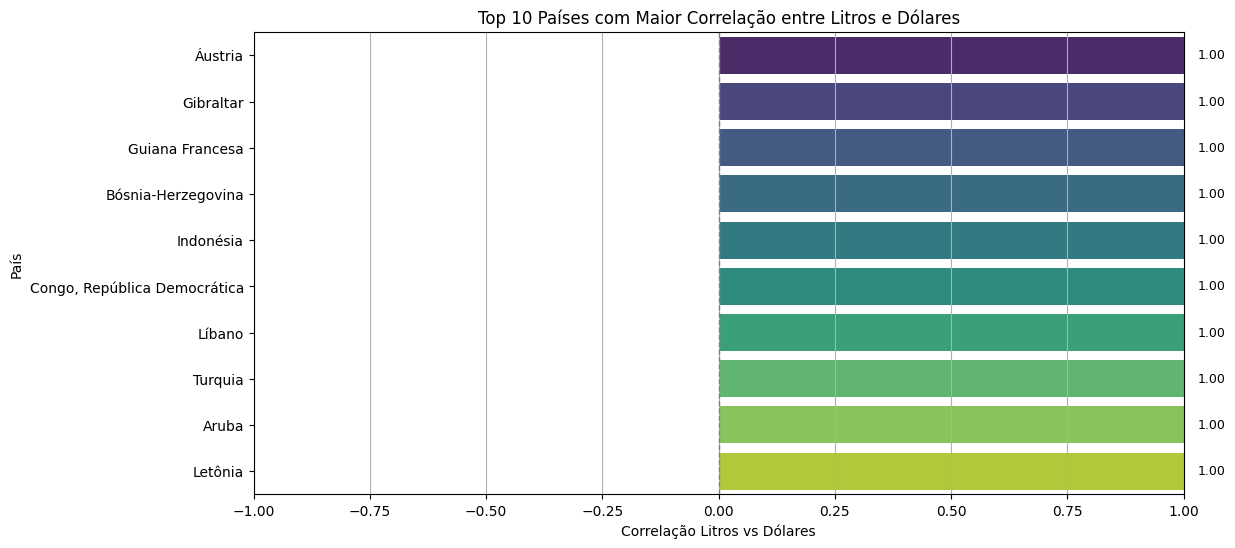

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ================================
# Base segura para correlação
base = df_pivotado[['País', 'litros', 'dolares']].copy()
base['litros']  = pd.to_numeric(base['litros'], errors='coerce')
base['dolares'] = pd.to_numeric(base['dolares'], errors='coerce')
base = base.dropna(subset=['litros','dolares'])

# Manter apenas países com ao menos 2 pontos válidos e variância > 0
def _ok(g):
    g2 = g[['litros','dolares']].dropna()
    if len(g2) < 2:
        return False
    return (g2['litros'].std(ddof=0) > 0) and (g2['dolares'].std(ddof=0) > 0)

base_valid = base.groupby('País', group_keys=False).filter(_ok)

# ================================
# Correlação por país (sem FutureWarning do pandas)
correlation_by_country = (
    base_valid
      .groupby('País')[['litros','dolares']]
      .apply(lambda g: g['litros'].corr(g['dolares']))
      .rename('Correlação Litros vs Dólares')
      .to_frame()
      .dropna()
)

# ================================
# Ordenar e selecionar top/bottom 10
correlation_sorted_asc  = correlation_by_country.sort_values(by='Correlação Litros vs Dólares', ascending=True)
lowest_correlation_countries  = correlation_sorted_asc.head(10).reset_index()   # -> tem col 'País'
correlation_sorted_desc = correlation_by_country.sort_values(by='Correlação Litros vs Dólares', ascending=False)
highest_correlation_countries = correlation_sorted_desc.head(10).reset_index()

# ================================
# Gráfico 1 — Menores correlações (mesmo layout/medidas/paleta)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=lowest_correlation_countries,
    x='Correlação Litros vs Dólares',
    y='País',
    hue='País',                 # evita FutureWarning do seaborn
    palette='viridis',
    dodge=False,
    legend=False
)
plt.title('Top 10 Países com Menor Correlação entre Litros e Dólares')
plt.xlabel('Correlação Litros vs Dólares')
plt.ylabel('País')
plt.xlim(-1, 1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(axis='x')

# rótulos numéricos
for i, v in enumerate(lowest_correlation_countries['Correlação Litros vs Dólares']):
    plt.text(v + (0.03 if v >= 0 else -0.03), i, f'{v:.2f}',
             ha='left' if v >= 0 else 'right', va='center', fontsize=9)
plt.show()

# ================================
# Gráfico 2 — Maiores correlações (mesmo layout/medidas/paleta)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=highest_correlation_countries,
    x='Correlação Litros vs Dólares',
    y='País',
    hue='País',
    palette='viridis',
    dodge=False,
    legend=False
)
plt.title('Top 10 Países com Maior Correlação entre Litros e Dólares')
plt.xlabel('Correlação Litros vs Dólares')
plt.ylabel('País')
plt.xlim(-1, 1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(axis='x')

for i, v in enumerate(highest_correlation_countries['Correlação Litros vs Dólares']):
    plt.text(v + (0.03 if v >= 0 else -0.03), i, f'{v:.2f}',
             ha='left' if v >= 0 else 'right', va='center', fontsize=9)
plt.show()


### Análise Temporal – Agregando por País e Ano

,País,ANO,Total_Litros,Total_Dolares,Media_Litros,Media_Dolares
0,Afeganistão,2021,13,46,13.0,46.0
1,Alemanha,2009,70616,354013,70616.0,354013.0
2,Alemanha,2010,26731,145543,26731.0,145543.0
3,Alemanha,2011,31889,153969,31889.0,153969.0
4,Alemanha,2012,7817,58551,7817.0,58551.0
5,Alemanha,2013,64690,296439,64690.0,296439.0
6,Alemanha,2014,221537,823822,221537.0,823822.0
7,Alemanha,2015,16933,75722,16933.0,75722.0
8,Alemanha,2016,13155,87197,13155.0,87197.0
9,Alemanha,2017,20318,117531,20318.0,117531.0


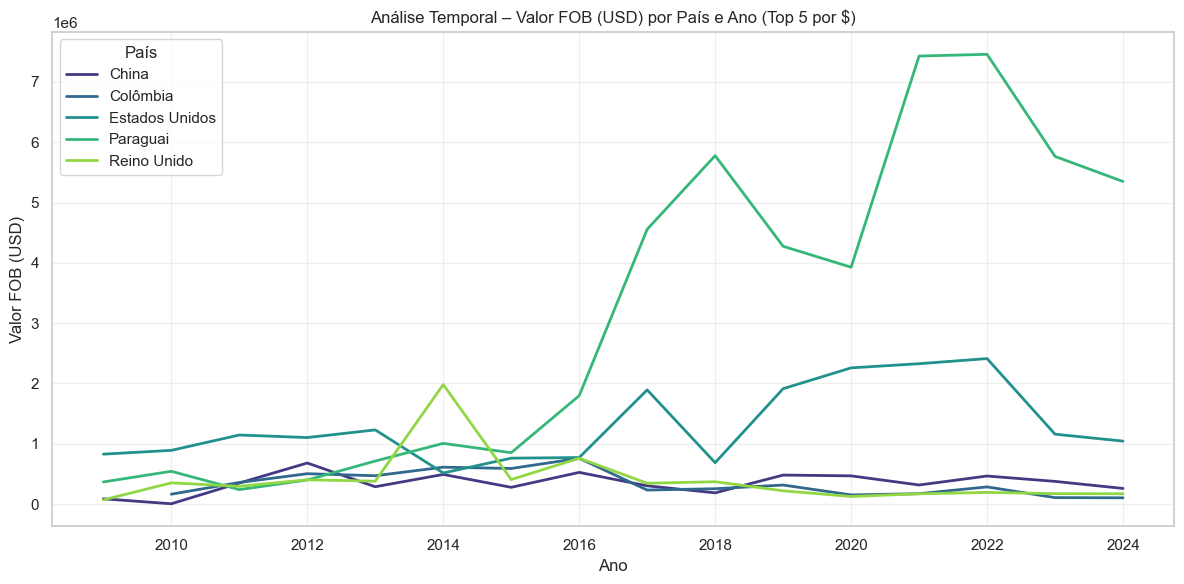

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Garantir tipos
tmp = df_pivotado.copy()
tmp['ANO'] = pd.to_numeric(tmp['ANO'], errors='coerce')
tmp['litros'] = pd.to_numeric(tmp['litros'], errors='coerce')
tmp['dolares'] = pd.to_numeric(tmp['dolares'], errors='coerce')
tmp = tmp.dropna(subset=['ANO','País','litros','dolares'])

# Agregar por País e Ano (somas e médias)
df_temporal = (
    tmp.groupby(['País','ANO'], as_index=False)
       .agg(Total_Litros=('litros','sum'),
            Total_Dolares=('dolares','sum'),
            Media_Litros=('litros','mean'),
            Media_Dolares=('dolares','mean'))
)

display(df_temporal.head(10))

# Para não poluir, plotar apenas TOP 5 países por valor total no período
top5 = (df_temporal.groupby('País')['Total_Dolares'].sum()
        .sort_values(ascending=False).head(5).index)
df_top = df_temporal[df_temporal['País'].isin(top5)]

sns.set(style='whitegrid', font_scale=1.0)
plt.figure(figsize=(12,6))
sns.lineplot(data=df_top, x='ANO', y='Total_Dolares', hue='País', linewidth=2, palette='viridis')
plt.title('Análise Temporal – Valor FOB (USD) por País e Ano (Top 5 por $)')
plt.xlabel('Ano'); plt.ylabel('Valor FOB (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Top 10 países em quantidade de litros 
##### Pergunta de negócio: Quais são nossos maiores clientes?

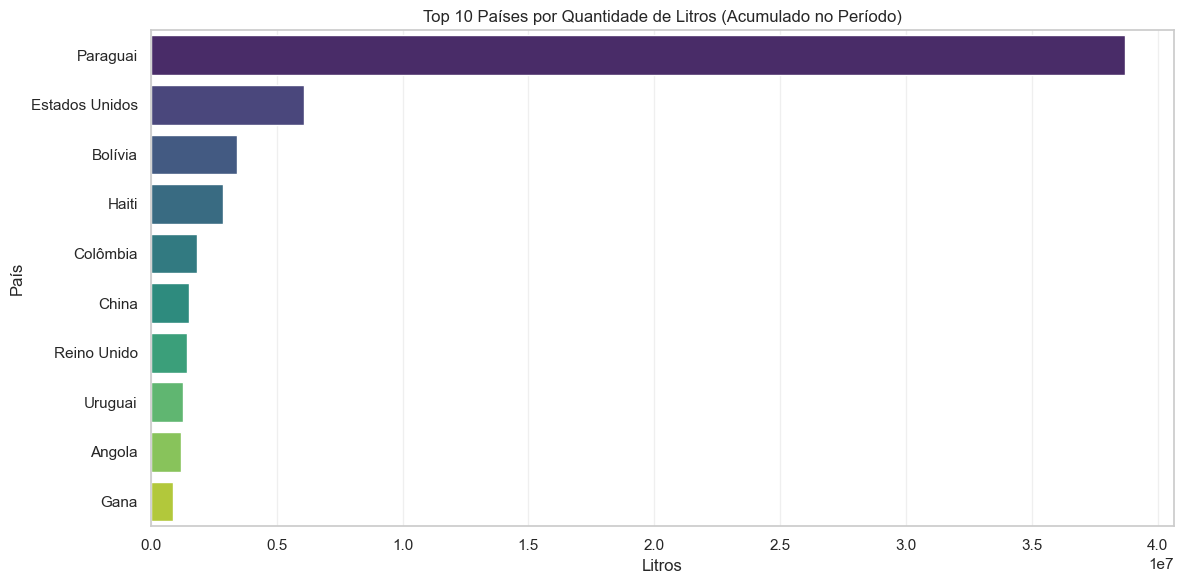

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

base = df_pivotado.copy()
base['litros'] = pd.to_numeric(base['litros'], errors='coerce')
base = base.dropna(subset=['País','litros'])


rank_litros = (base.groupby('País', as_index=False)['litros'].sum().sort_values('litros', ascending=False).head(10)) # type: ignore

plt.figure(figsize=(12,6))
sns.barplot(data=rank_litros, x='litros', y='País', hue='País', palette='viridis', legend=False)
plt.title('Top 10 Países por Quantidade de Litros (Acumulado no Período)')
plt.xlabel('Litros'); plt.ylabel('País')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### Preço por litro por país e ano

Comparando os anos: 2023 × 2024


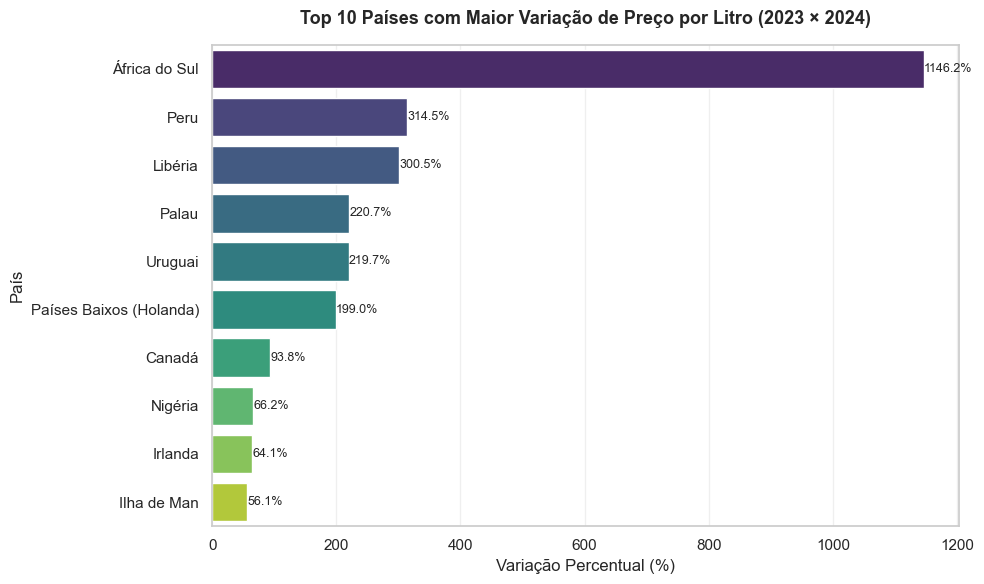

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Preparar base
tmp = df_pivotado.copy()
tmp['ANO'] = pd.to_numeric(tmp['ANO'], errors='coerce')
tmp['litros'] = pd.to_numeric(tmp['litros'], errors='coerce')
tmp['dolares'] = pd.to_numeric(tmp['dolares'], errors='coerce')
tmp = tmp.dropna(subset=['ANO', 'País', 'litros', 'dolares'])

# Agregar por país e ano
agg = (tmp.groupby(['País', 'ANO'], as_index=False)
          .agg(Total_Litros=('litros', 'sum'),
               Total_Dolares=('dolares', 'sum')))
agg['preco_por_litro'] = np.where(
    agg['Total_Litros'] > 0,
    agg['Total_Dolares'] / agg['Total_Litros'],
    np.nan
)

# ================================
# Descobrir os dois últimos anos disponíveis
anos_disponiveis = sorted(agg['ANO'].dropna().unique())
ano_inicio = anos_disponiveis[-2] if len(anos_disponiveis) >= 2 else anos_disponiveis[0]
ano_fim = anos_disponiveis[-1]

print(f"Comparando os anos: {ano_inicio} × {ano_fim}")

# ================================
# Filtrar apenas países com dados válidos nos dois anos
df_start = agg[agg['ANO'] == ano_inicio][['País', 'preco_por_litro']].rename(columns={'preco_por_litro': 'inicio'})
df_end = agg[agg['ANO'] == ano_fim][['País', 'preco_por_litro']].rename(columns={'preco_por_litro': 'fim'})
df_slope = pd.merge(df_start, df_end, on='País').dropna()

# Calcular variação percentual
df_slope['var_percentual'] = ((df_slope['fim'] - df_slope['inicio']) / df_slope['inicio']) * 100

# Selecionar top 10 países com maior variação
df_top = df_slope.sort_values('var_percentual', ascending=False).head(10)

# ================================
# Gráfico de barras moderno (sem warnings)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
palette = sns.color_palette("viridis", len(df_top))

sns.barplot(
    data=df_top,
    y='País',
    x='var_percentual',
    hue='País',              # evita FutureWarning
    palette=palette,
    legend=False
)

# Rótulos
for i, v in enumerate(df_top['var_percentual']):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.title(f'Top 10 Países com Maior Variação de Preço por Litro ({int(ano_inicio)} × {int(ano_fim)})',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Variação Percentual (%)')
plt.ylabel('País')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Top 10 países em preço por litro
##### preço médio ponderado no período: soma($)/soma(litros)

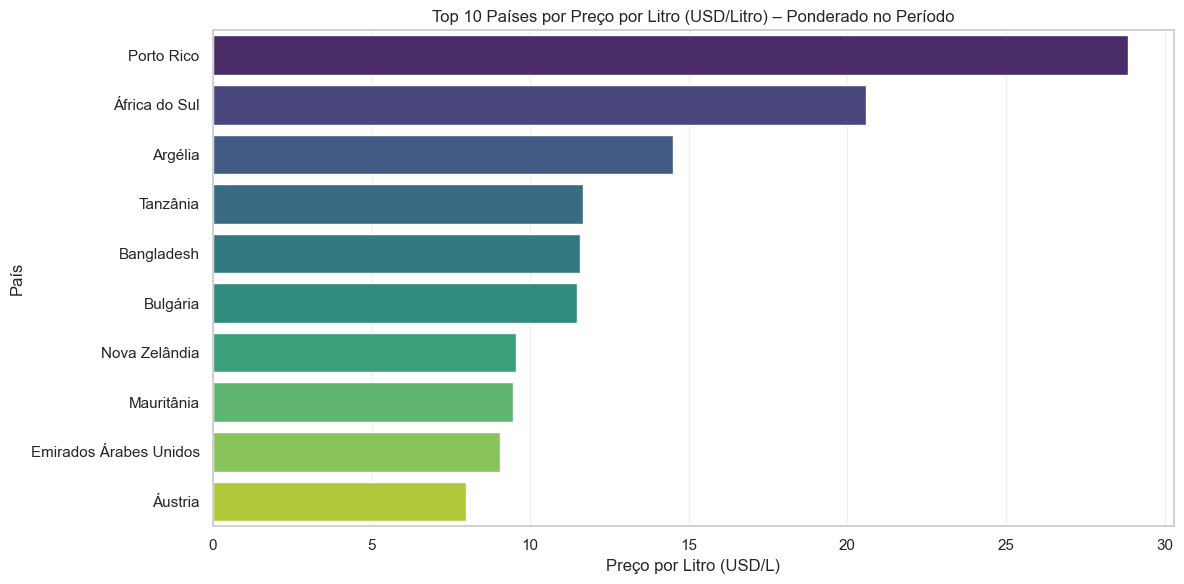

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base = df_pivotado.copy()
base['litros'] = pd.to_numeric(base['litros'], errors='coerce')
base['dolares'] = pd.to_numeric(base['dolares'], errors='coerce')
base = base.dropna(subset=['País','litros','dolares'])

w = (base.groupby('País', as_index=False)
         .agg(Total_Litros=('litros','sum'),
              Total_Dolares=('dolares','sum')))
w = w[w['Total_Litros'] > 0].copy()
w['preco_por_litro'] = w['Total_Dolares']/w['Total_Litros']

top10_price = w.sort_values('preco_por_litro', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top10_price, x='preco_por_litro', y='País', hue='País', palette='viridis', legend=False)
plt.title('Top 10 Países por Preço por Litro (USD/Litro) – Ponderado no Período')
plt.xlabel('Preço por Litro (USD/L)'); plt.ylabel('País')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### Evolução por país
##### Gera, para cada país selecionado, 2 linhas (dólares e litros) ao longo dos anos em subplots lado a lado

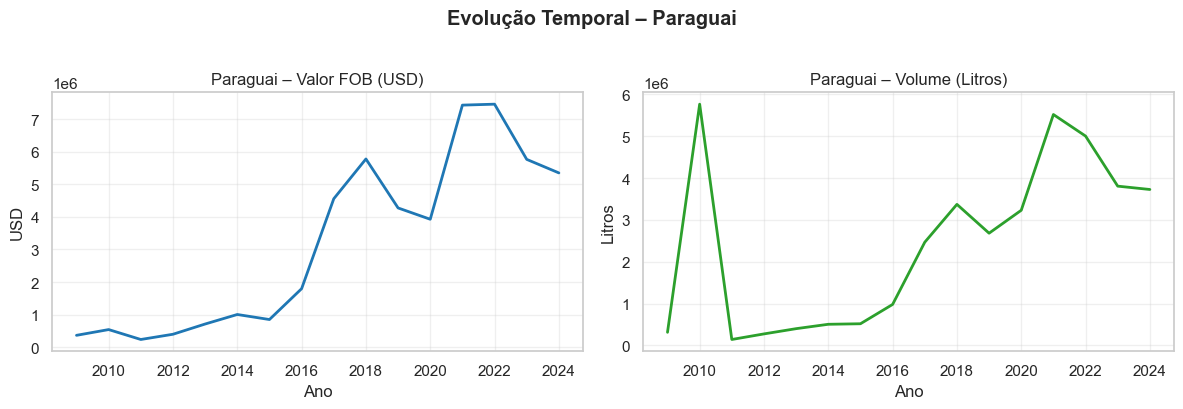

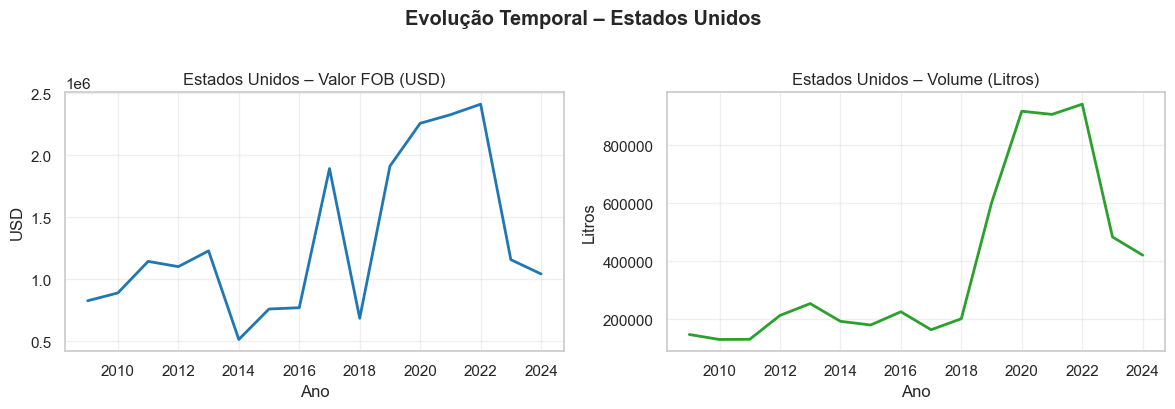

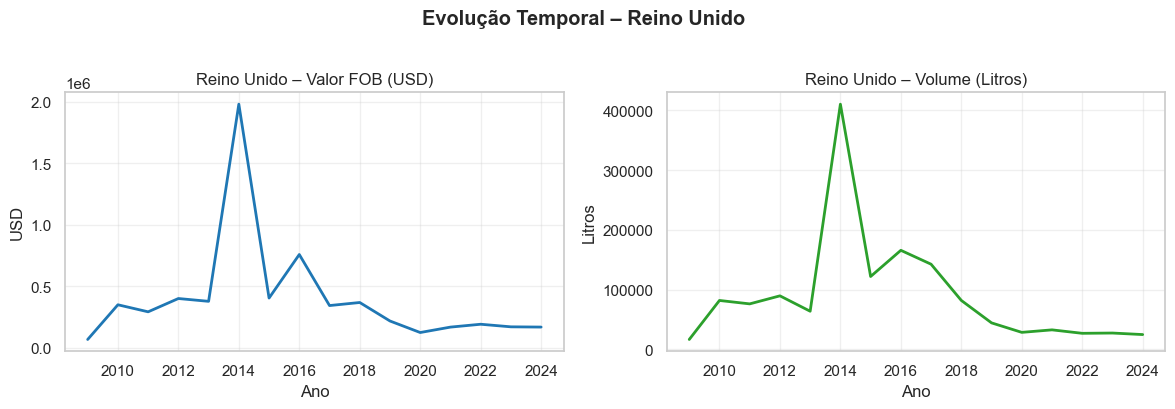

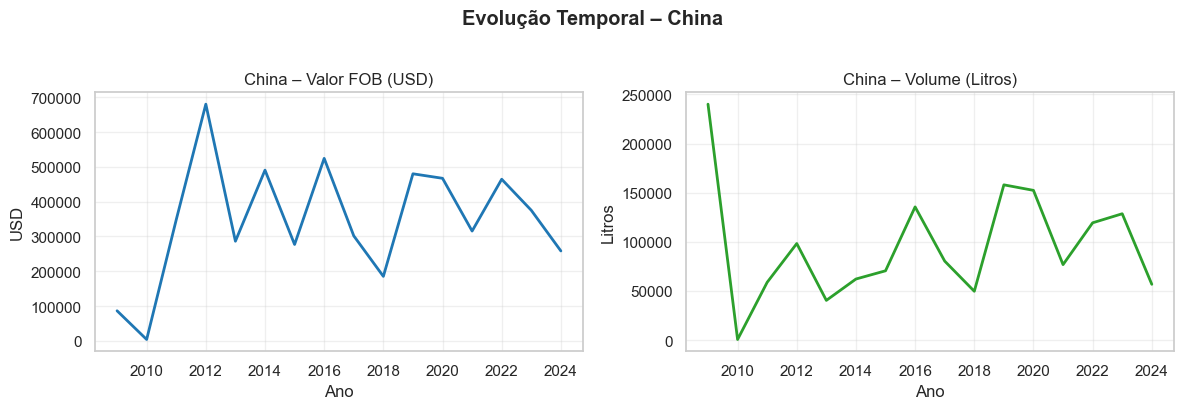

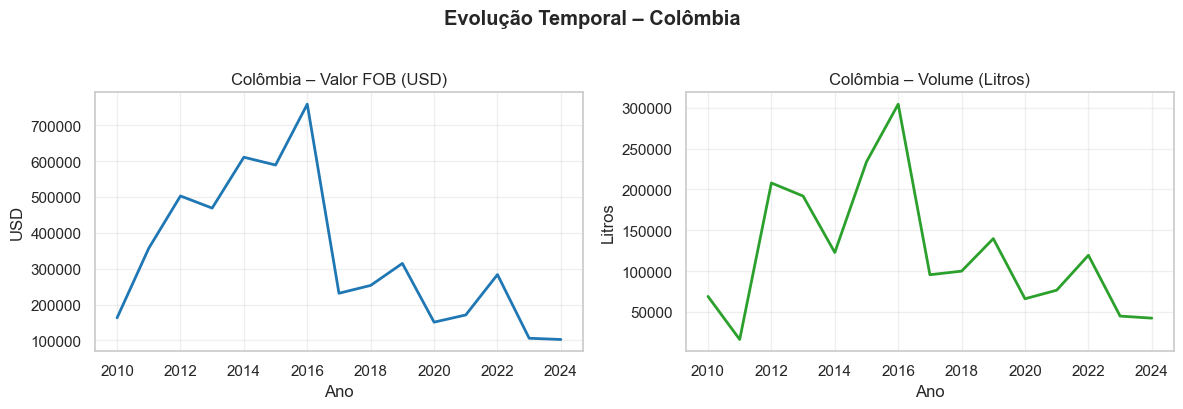

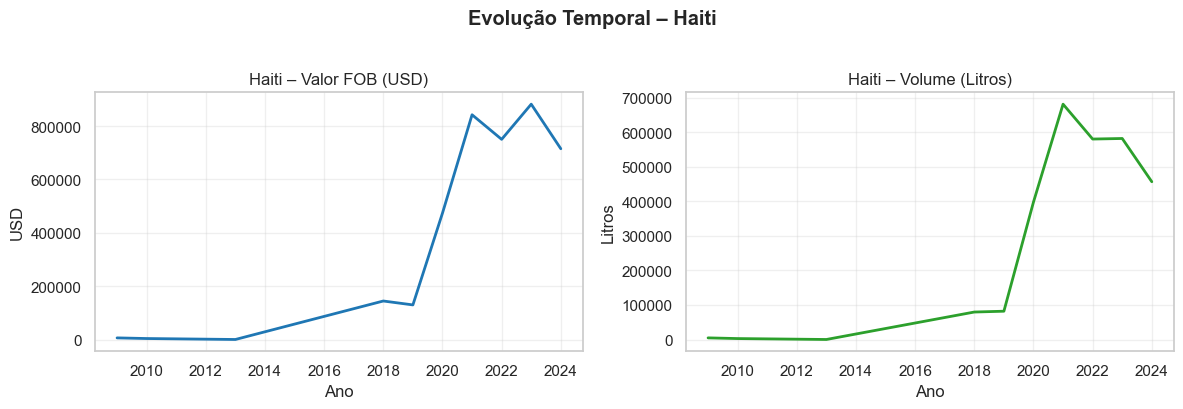

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

tmp = df_pivotado.copy()
tmp['ANO'] = pd.to_numeric(tmp['ANO'], errors='coerce')
tmp['litros'] = pd.to_numeric(tmp['litros'], errors='coerce')
tmp['dolares'] = pd.to_numeric(tmp['dolares'], errors='coerce')
tmp = tmp.dropna(subset=['ANO','País','litros','dolares'])

# Seleção de países (ajuste: pode ser top 6 por $)
sel = (tmp.groupby('País')['dolares'].sum()
          .sort_values(ascending=False).head(6).index)

for pais in sel:
    dfc = (tmp[tmp['País']==pais]
           .groupby('ANO', as_index=False)
           .agg(Total_Litros=('litros','sum'),
                Total_Dolares=('dolares','sum')))
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4), sharex=True)
    sns.lineplot(data=dfc, x='ANO', y='Total_Dolares', ax=ax1, linewidth=2, color='tab:blue')
    ax1.set_title(f'{pais} – Valor FOB (USD)'); ax1.set_xlabel('Ano'); ax1.set_ylabel('USD'); ax1.grid(True, alpha=0.3)
    sns.lineplot(data=dfc, x='ANO', y='Total_Litros', ax=ax2, linewidth=2, color='tab:green')
    ax2.set_title(f'{pais} – Volume (Litros)'); ax2.set_xlabel('Ano'); ax2.set_ylabel('Litros'); ax2.grid(True, alpha=0.3)
    plt.suptitle(f'Evolução Temporal – {pais}', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


### Gráficos anuais dos top 10 países × preços por litro
##### gera o gráfico para o ano mais recente

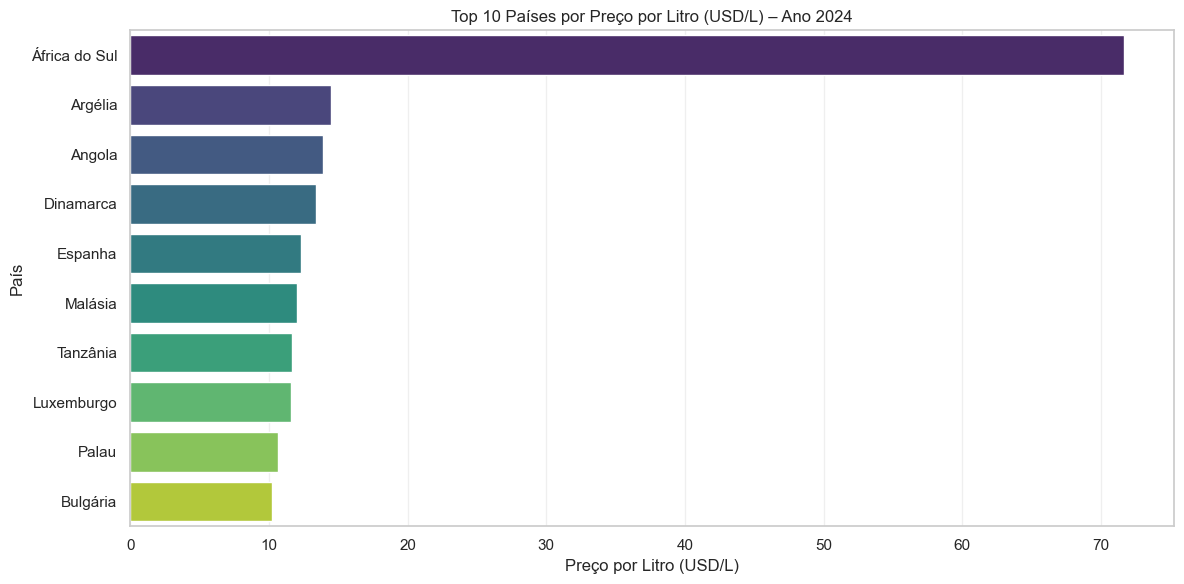

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tmp = df_pivotado.copy()
tmp['ANO'] = pd.to_numeric(tmp['ANO'], errors='coerce')
tmp['litros'] = pd.to_numeric(tmp['litros'], errors='coerce')
tmp['dolares'] = pd.to_numeric(tmp['dolares'], errors='coerce')
tmp = tmp.dropna(subset=['ANO','País','litros','dolares'])
tmp = tmp[tmp['litros'] > 0].copy()
tmp['preco_por_litro'] = tmp['dolares']/tmp['litros']

ano_ref = int(tmp['ANO'].max())  # último ano disponível
df_year = tmp[tmp['ANO']==ano_ref].copy()

# Garantir que temos um DataFrame (não uma Series) antes de usar nlargest
avg_price = df_year.groupby('País', as_index=False).agg(preco_por_litro=('preco_por_litro', 'mean'))
top10_year = avg_price.nlargest(10, 'preco_por_litro')

plt.figure(figsize=(12,6))
sns.barplot(data=top10_year, x='preco_por_litro', y='País', hue='País', palette='viridis', legend=False)
plt.title(f'Top 10 Países por Preço por Litro (USD/L) – Ano {ano_ref}')
plt.xlabel('Preço por Litro (USD/L)'); plt.ylabel('País')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Iterar por ano e gerar gráficos (>= 2020)

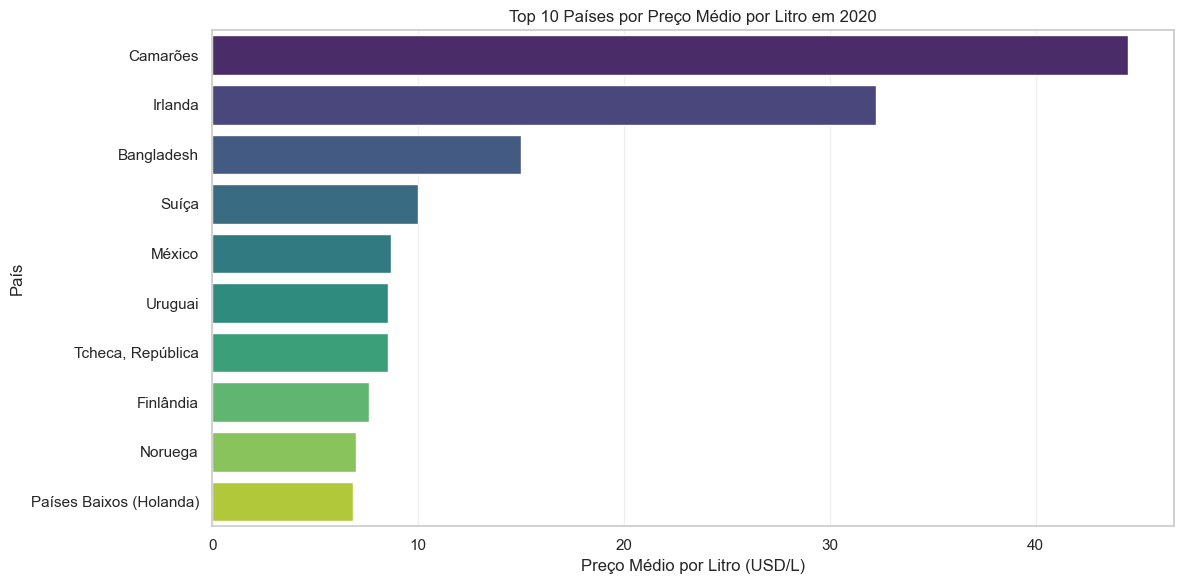

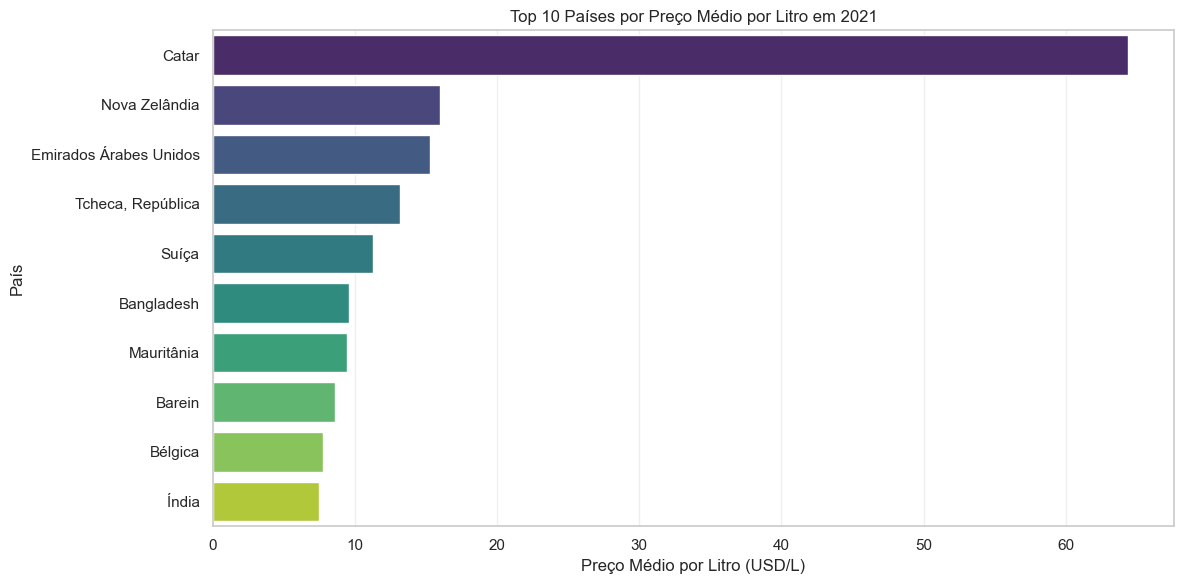

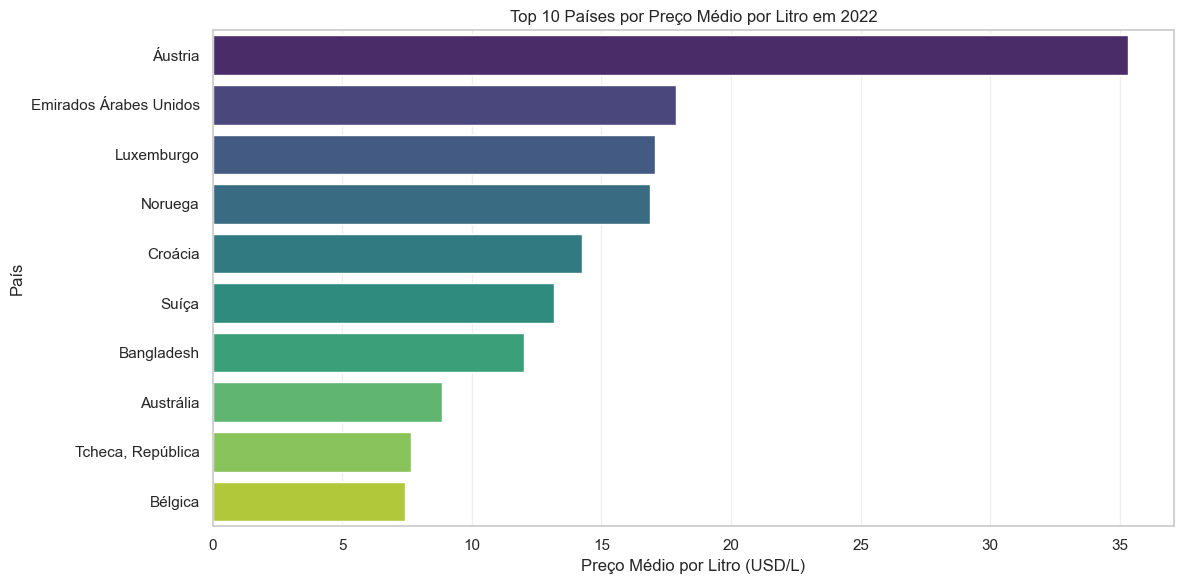

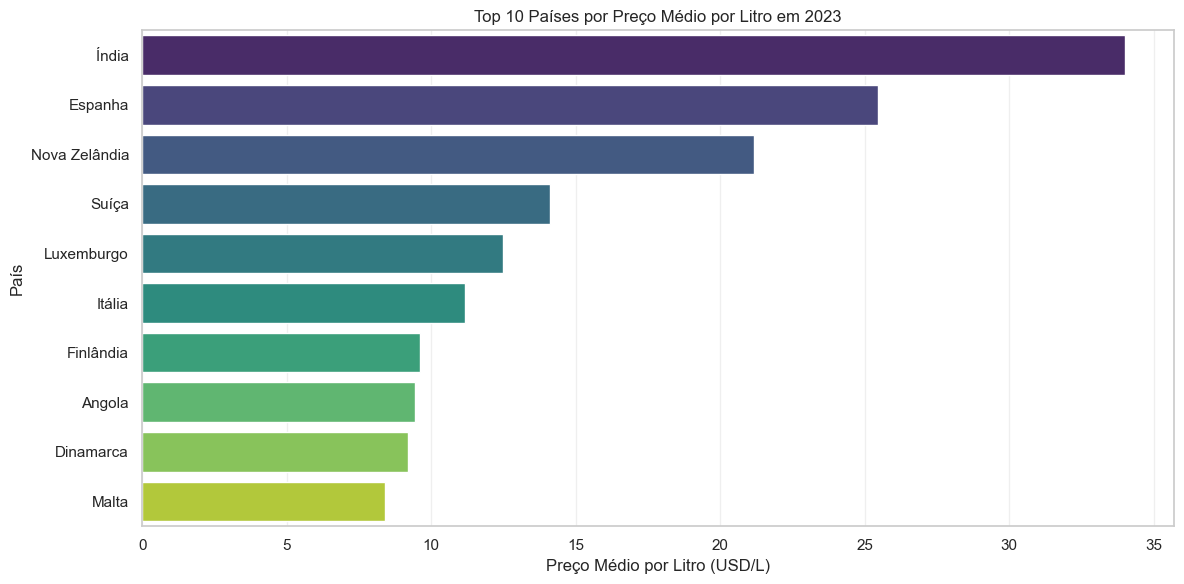

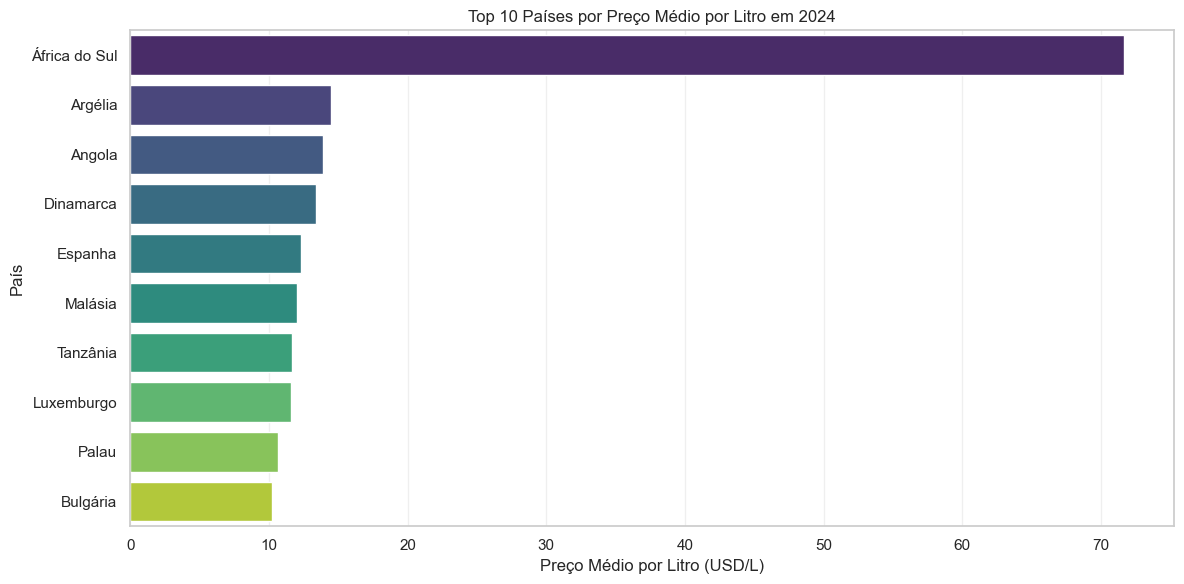

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar base com preco_por_litro
tmp = df_pivotado.copy()
tmp['ANO'] = pd.to_numeric(tmp['ANO'], errors='coerce')
tmp['litros'] = pd.to_numeric(tmp['litros'], errors='coerce')
tmp['dolares'] = pd.to_numeric(tmp['dolares'], errors='coerce')
tmp = tmp.dropna(subset=['ANO','País','litros','dolares'])
tmp = tmp[tmp['litros'] > 0].copy()
tmp['preco_por_litro'] = tmp['dolares']/tmp['litros']

# anos únicos recentes (>= 2020)
anos_unicos = sorted(tmp['ANO'].dropna().unique().tolist())
anos_recentes = [int(y) for y in anos_unicos if y >= 2020]

for year in anos_recentes:
    df_year = tmp[tmp['ANO'] == year].copy()

    # Garantir que obtemos um DataFrame com a média por país (evita retornar Series)
    average_price_year = df_year.groupby('País', as_index=False).agg(
        preco_por_litro=('preco_por_litro', 'mean')
    )

    # usar DataFrame.nlargest para retornar um DataFrame (tipagem correta)
    top_10_paises_preco_year = average_price_year.nlargest(10, 'preco_por_litro')

    if not top_10_paises_preco_year.empty:
        plt.figure(figsize=(12, 6))
        sns.barplot(
            x='preco_por_litro',
            y='País',
            data=top_10_paises_preco_year,
            hue='País',
            palette='viridis',
            dodge=False,
            legend=False
        )
        plt.title(f'Top 10 Países por Preço Médio por Litro em {year}')
        plt.xlabel('Preço Médio por Litro (USD/L)'); plt.ylabel('País')
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

## Prospecções Futuras e Recomendações (LinearRegression com fallback)

In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# =========================================================
# 0) Garantir df_temporal no formato esperado
#    Esperado: colunas 'Ano' (int) e 'Total_Exportado_Litros' (float)
if 'df_temporal' not in globals() or not set(['Ano','Total_Exportado_Litros']).issubset(set(df_temporal.columns)):
    # Fallback a partir do df_pivotado (País, ANO, litros, dolares)
    df_tmp = df_pivotado.copy()
    df_tmp['ANO'] = pd.to_numeric(df_tmp['ANO'], errors='coerce')
    df_tmp['litros'] = pd.to_numeric(df_tmp['litros'], errors='coerce')
    df_tmp = df_tmp.dropna(subset=['ANO','litros'])
    # usar agg para agregar e evitar possíveis avisos de tipagem no rename
    df_temporal = (
        df_tmp.groupby('ANO', as_index=False)
              .agg(Total_Exportado_Litros=('litros', 'sum'))
              .rename(columns={'ANO': 'Ano'})
    )

# Ordenar e manter uma única linha por ano
df_temporal = df_temporal[['Ano','Total_Exportado_Litros']].dropna().drop_duplicates(subset=['Ano']).sort_values('Ano')

# =========================================================
# 1) Preparar dados para regressão
# usar to_numpy() para garantir um ndarray (evita ExtensionArray sem reshape)
X = df_temporal['Ano'].to_numpy().reshape(-1, 1)
y = df_temporal['Total_Exportado_Litros'].to_numpy()

# Checagens básicas
if len(np.unique(X)) < 2:
    raise ValueError("Necessário pelo menos 2 anos distintos para ajustar a regressão.")

modelo = LinearRegression()
modelo.fit(X, y)

# Descobrir último ano histórico e definir horizonte (próximos 5 anos)
ultimo_ano_hist = int(df_temporal['Ano'].max())
inicio_proj = ultimo_ano_hist + 1
fim_proj = ultimo_ano_hist + 5
anos_futuros = np.arange(inicio_proj, fim_proj + 1).reshape(-1, 1)

projecoes = modelo.predict(anos_futuros)
r2_score = modelo.score(X, y)
coef_ano = float(modelo.coef_[0])

# Base para % de crescimento = último ano histórico
base_hist = float(df_temporal.loc[df_temporal['Ano'] == ultimo_ano_hist, 'Total_Exportado_Litros'].iloc[0])

# Impressão executiva
print("PROJEÇÕES PARA OS PRÓXIMOS 5 ANOS")
print("=" * 40)
print(f"Modelo de Regressão Linear (R² = {r2_score:.3f})")
print(f"Tendência: {coef_ano:+,.0f} litros/ano\n")
print(f"{'Ano':<6} {'Projeção (Litros)':<20} {'Crescimento %':<15}")
print("-" * 45)

for i, ano in enumerate(range(inicio_proj, fim_proj + 1)):
    projecao = float(projecoes[i])
    crescimento = ((projecao / base_hist) - 1) * 100 if base_hist > 0 else np.nan
    print(f"{ano:<6} {projecao:>15,.0f} {crescimento:>12.1f}%")

# Cenários alternativos para o último ano projetado
projecao_final = float(projecoes[-1])
print("\nCENÁRIOS ALTERNATIVOS PARA", fim_proj)
print("=" * 35)
print(f"Cenário Conservador (-20%): {projecao_final * 0.8:,.0f} litros")
print(f"Cenário Base (tendência):   {projecao_final:,.0f} litros")
print(f"Cenário Otimista (+30%):    {projecao_final * 1.3:,.0f} litros")

# =========================================================
# 2) Recomendações automáticas (baseadas em sinais simples)
print("\nRECOMENDAÇÕES")
print("=" * 15)
if r2_score >= 0.6 and coef_ano > 0:
    print("- Reforçar capacidade de produção e logística: tendência de alta com boa explicação (R² ≥ 0.6).")
elif r2_score < 0.6:
    print("- Variabilidade alta no histórico (R² baixo): reavaliar drivers (câmbio, mix, sazonalidade) e usar modelos não-lineares.")
if coef_ano > 0:
    print("- Priorizar mercados com elasticidade positiva (volume→receita) e ampliar mix premium.")
else:
    print("- Foco em eficiência e preço por litro: tendência de queda sugere revisão de portfólio e canais.")
print("- Simular cenários com choques de preço/câmbio e campanhas (ex.: ±20% no preço, ±10% no volume).")


PROJEÇÕES PARA OS PRÓXIMOS 5 ANOS
Modelo de Regressão Linear (R² = 0.289)
Tendência: +302,993 litros/ano

Ano    Projeção (Litros)    Crescimento %  
---------------------------------------------
2025         6,794,722         14.9%
2026         7,097,716         20.0%
2027         7,400,709         25.1%
2028         7,703,703         30.2%
2029         8,006,696         35.4%

CENÁRIOS ALTERNATIVOS PARA 2029
Cenário Conservador (-20%): 6,405,357 litros
Cenário Base (tendência):   8,006,696 litros
Cenário Otimista (+30%):    10,408,705 litros

RECOMENDAÇÕES
- Variabilidade alta no histórico (R² baixo): reavaliar drivers (câmbio, mix, sazonalidade) e usar modelos não-lineares.
- Priorizar mercados com elasticidade positiva (volume→receita) e ampliar mix premium.
- Simular cenários com choques de preço/câmbio e campanhas (ex.: ±20% no preço, ±10% no volume).


### Exportações: Histórico e Projeções (Litros)

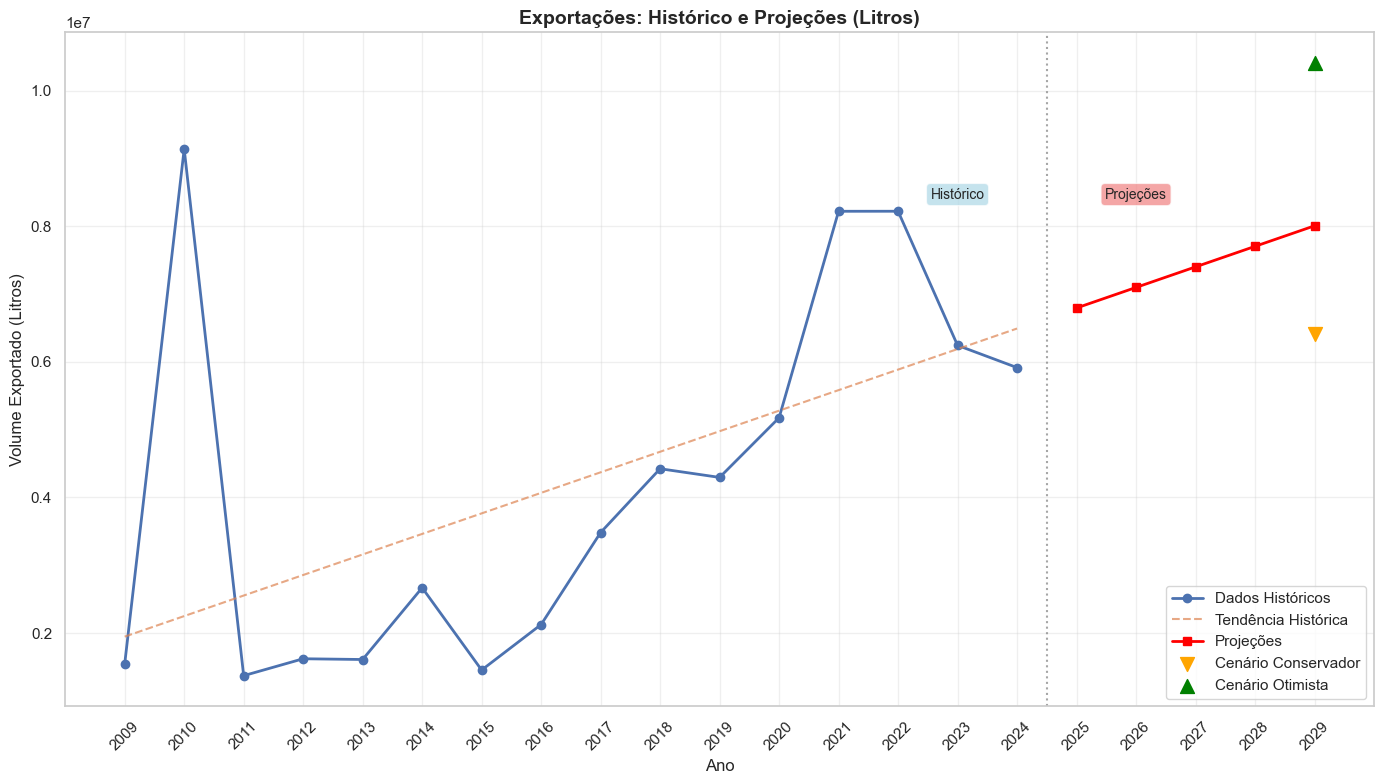

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Reutiliza variáveis da célula anterior:
# df_temporal, modelo, X, projecoes, anos_futuros, ultimo_ano_hist, base_hist, fim_proj

plt.figure(figsize=(14, 8))

# Dados históricos
plt.plot(df_temporal['Ano'], df_temporal['Total_Exportado_Litros'],
         'o-', linewidth=2, markersize=6, label='Dados Históricos')

# Linha de tendência histórica
tend_hist = modelo.predict(X)
plt.plot(df_temporal['Ano'], tend_hist,
         '--', alpha=0.7, label='Tendência Histórica')

# Projeções futuras
anos_futuros_plot = anos_futuros.flatten().tolist()
plt.plot(anos_futuros_plot, projecoes,
         's-', color='red', linewidth=2, markersize=6, label='Projeções')

# Cenários alternativos para o último ano projetado
plt.scatter([fim_proj], [projecoes[-1] * 0.8], color='orange', s=100, marker='v', label='Cenário Conservador')
plt.scatter([fim_proj], [projecoes[-1] * 1.3], color='green',  s=100, marker='^', label='Cenário Otimista')

plt.title('Exportações: Histórico e Projeções (Litros)', fontsize=14, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Volume Exportado (Litros)')
plt.grid(True, alpha=0.3)

# Eixo X com anos históricos + futuros
xt = df_temporal['Ano'].tolist() + anos_futuros_plot
plt.xticks(sorted(set(xt)), rotation=45)

# Linha vertical separando histórico de projeções
plt.axvline(x=ultimo_ano_hist + 0.5, color='gray', linestyle=':', alpha=0.7)
ymax = max(df_temporal['Total_Exportado_Litros'].max(), float(np.nanmax(projecoes)))
plt.text(ultimo_ano_hist - 1, ymax * 0.92, 'Histórico',
         fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightblue',  alpha=0.7))
plt.text(ultimo_ano_hist + 2, ymax * 0.92, 'Projeções',
         fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

plt.legend()
plt.tight_layout()
plt.show()


### Recomendações Estratégicas para Melhoria das Exportações

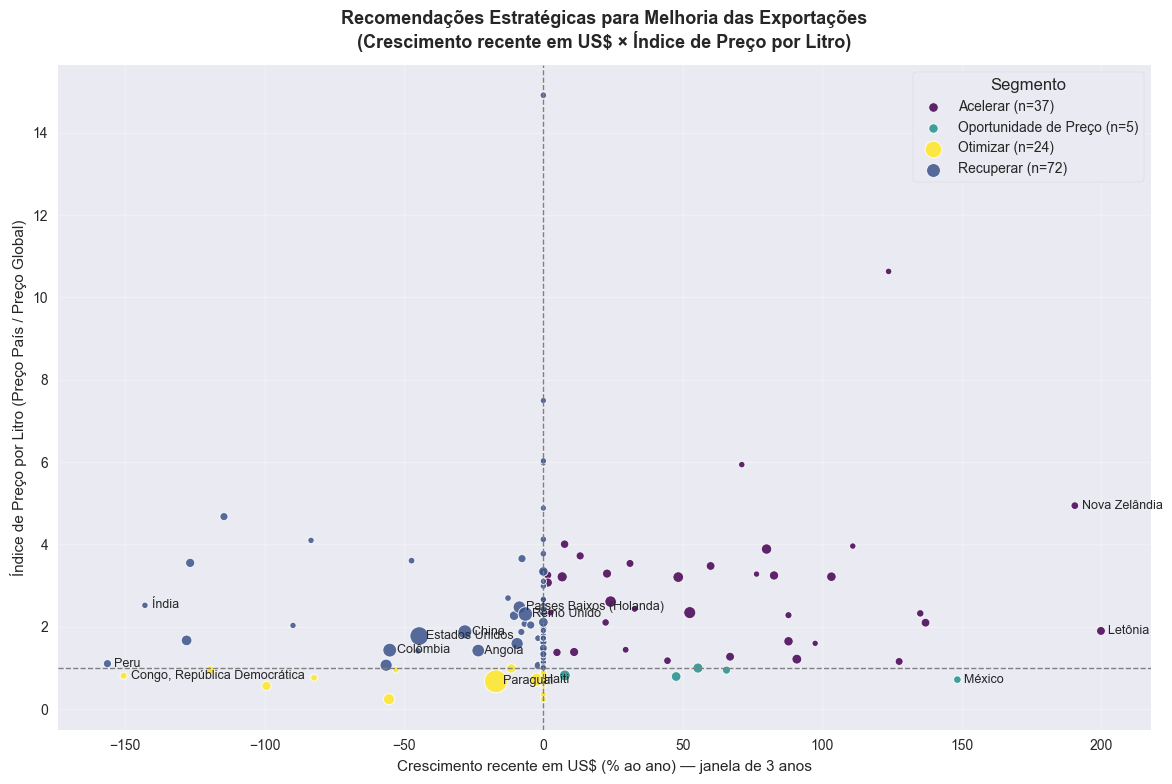


=== RESUMO POR SEGMENTO ===
- Acelerar: 37 país(es) | Top: Alemanha, Bélgica, Canadá, Suíça, França
- Oportunidade de Preço: 5 país(es) | Top: Gana, Venezuela, Togo, Serra Leoa, México
- Recuperar: 72 país(es) | Top: Estados Unidos, Reino Unido, China, Colômbia, Angola
- Otimizar: 24 país(es) | Top: Paraguai, Haiti, Bolívia, Curaçao, Rússia


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Recomendações Estratégicas para Melhoria das Exportações
# =========================================================

# --- Preparar base ---
tmp = df_pivotado.copy()
tmp['ANO']     = pd.to_numeric(tmp['ANO'], errors='coerce')
tmp['litros']  = pd.to_numeric(tmp['litros'], errors='coerce')
tmp['dolares'] = pd.to_numeric(tmp['dolares'], errors='coerce')
tmp = tmp.dropna(subset=['ANO','País','litros','dolares'])

agg = (tmp.groupby(['País','ANO'], as_index=False)
         .agg(litros=('litros','sum'),
              dolares=('dolares','sum')))
agg['preco_litro'] = np.where(agg['litros']>0, agg['dolares']/agg['litros'], np.nan)

# --- Métricas globais ---
anos_ord = np.sort(agg['ANO'].unique())
janela = 3 if len(anos_ord) >= 3 else len(anos_ord)
anos_recent = anos_ord[-janela:]

glob = agg[['litros','dolares']].sum()
preco_global = glob['dolares']/glob['litros'] if glob['litros']>0 else np.nan

pais_periodo = (agg.groupby('País', as_index=False)
                  .agg(dolares_sum=('dolares','sum')))
total_dolares = pais_periodo['dolares_sum'].sum()
pais_periodo['share_$'] = np.where(total_dolares>0, pais_periodo['dolares_sum']/total_dolares, 0.0)

# --- Função auxiliar ---
def lin_slope_percent(anos, valores):
    x = np.array(anos, dtype=float)
    y = np.array(valores, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 2 or np.allclose(y, y.mean()):
        return 0.0
    coef = np.polyfit(x, y, deg=1)
    slope = coef[0]
    base  = y.mean() if y.mean()!=0 else (np.abs(y).mean()+1e-9)
    return (slope / base) * 100.0

# --- KPIs por país ---
linhas = []
for pais, g in agg.groupby('País'):
    g_recent = g[g['ANO'].isin(anos_recent)].sort_values('ANO')
    slope_pct = lin_slope_percent(g_recent['ANO'], g_recent['dolares'])
    litros_tot, dolares_tot = g['litros'].sum(), g['dolares'].sum()
    preco_med = (dolares_tot / litros_tot) if litros_tot>0 else np.nan
    price_idx = (preco_med / preco_global) if np.isfinite(preco_global) and preco_global>0 else np.nan
    share_val = pais_periodo.loc[pais_periodo['País']==pais, 'share_$']
    share = float(share_val.iloc[0]) if not share_val.empty else 0.0
    linhas.append((pais, slope_pct, preco_med, price_idx, share))

df_rec = pd.DataFrame(linhas, columns=['País','slope_%_USD_ano','preco_medio','price_index','share_$']).replace([np.inf,-np.inf], np.nan)
df_rec = df_rec.dropna(subset=['price_index'])

# --- Segmentação ---
def segmentar(row):
    if row['slope_%_USD_ano'] > 0 and row['price_index'] >= 1.0:
        return 'Acelerar'
    if row['slope_%_USD_ano'] <= 0 and row['price_index'] >= 1.0:
        return 'Recuperar'
    if row['slope_%_USD_ano'] > 0 and row['price_index'] < 1.0:
        return 'Oportunidade de Preço'
    return 'Otimizar'

df_rec['Segmento'] = df_rec.apply(segmentar, axis=1)

# --- Gráfico Estratégico ---
plt.figure(figsize=(12, 8))
plt.style.use('seaborn-v0_8')

cores_seg = {
    'Acelerar':              (68/255,   1/255,  84/255),
    'Recuperar':             (59/255,  82/255, 139/255),
    'Oportunidade de Preço': (33/255, 145/255, 140/255),
    'Otimizar':              (253/255, 231/255,  37/255)
}

for seg, g in df_rec.groupby('Segmento'):
    plt.scatter(
        g['slope_%_USD_ano'], g['price_index'],
        s=400 * np.sqrt(np.clip(g['share_$'].to_numpy(dtype=float), 0.0, 1.0)) + 20,
        alpha=0.85, edgecolor='white', linewidth=0.7,
        color=cores_seg.get(str(seg), (0.5, 0.5, 0.5)), label=f"{seg} (n={len(g)})"
    )

plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1)
plt.title('Recomendações Estratégicas para Melhoria das Exportações\n(Crescimento recente em US$ × Índice de Preço por Litro)',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Crescimento recente em US$ (% ao ano) — janela de {janela} anos')
plt.ylabel('Índice de Preço por Litro (Preço País / Preço Global)')

# --- Seleção de países para anotar ---
to_annot = pd.concat([
    df_rec.sort_values('share_$', ascending=False).head(8),
    df_rec.sort_values('slope_%_USD_ano', ascending=False).head(3),
    df_rec.sort_values('slope_%_USD_ano', ascending=True).head(3)
]).drop_duplicates(subset=['País'])

for _, r in to_annot.iterrows():
    plt.text(r['slope_%_USD_ano'], r['price_index'], '  ' + r['País'], va='center', fontsize=9)

plt.legend(title='Segmento', frameon=True, loc='best')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# --- Resumo Executivo ---
def top_str(df, k=5):
    if df.empty: return "—"
    return ", ".join(df.sort_values('share_$', ascending=False).head(k)['País'].tolist())

print("\n=== RESUMO POR SEGMENTO ===")
for seg in ['Acelerar','Oportunidade de Preço','Recuperar','Otimizar']:
    subset = df_rec[df_rec['Segmento']==seg]
    print(f"- {seg}: {len(subset)} país(es) | Top: {top_str(subset, 5)}")


In [22]:
import numpy as np
import pandas as pd
from pathlib import Path

CSV_PATH = Path("C:/Users/GUTO-GAMER/Desktop/FIAP/Database/dados_comercio_exterior/V_EXPORTACAO_GERAL_2009-01_2024-12_DT20251016.csv")
ANO_INI, ANO_FIM = 2009, 2024

def find_col(df, candidates):
    """Procura por uma coluna na lista candidates (case-insensitive, ignora acentos simples)."""
    cols_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        key = cand.lower()
        if key in cols_map:
            return cols_map[key]
    def norm(s): 
        return (s.lower()
                  .replace("ç","c").replace("ã","a").replace("á","a").replace("à","a")
                  .replace("â","a").replace("é","e").replace("ê","e")
                  .replace("í","i").replace("õ","o").replace("ó","o").replace("ô","o")
                  .replace("ú","u"))
    nmap = {norm(c): c for c in df.columns}
    for cand in candidates:
        key = norm(cand)
        if key in nmap:
            return nmap[key]
    return None

def to_numeric(series):
    return pd.to_numeric(series, errors="coerce")

# Selecionar a fonte
if "df_pivotado" in globals():
    src = df_pivotado.copy()
    col_ano    = find_col(src, ["ANO", "Ano", "year"])
    col_pais   = find_col(src, ["País", "PAISES", "Pais", "Países"])
    col_litros = find_col(src, ["litros", "LITROS", "Quantidade Estatística", "QT_ESTATISTICA", "Quilograma Líquido", "KG_LIQUIDO"])
    col_usd    = find_col(src, ["dolares", "Valor US$ FOB", "VALOR_FOB_USD", "Valor FOB (US$)", "VALOR_FOB"])
    assert col_ano and col_pais and col_litros and col_usd, "df_pivotado não possui as colunas esperadas."
else:
    if "df" in globals():
        raw = df.copy()
    else:
        if not CSV_PATH.exists():
            raise FileNotFoundError(f"Arquivo CSV não encontrado em: {CSV_PATH}")

        # Leitura robusta + limpeza de \r e espaços extras
        raw = pd.read_csv(CSV_PATH, sep=';', dtype=str, low_memory=False, encoding='utf-8', na_filter=False)
       

        for col in raw.select_dtypes(include='object').columns:
            raw[col] = raw[col].map(lambda x: x.strip().replace('\r', '').replace('\n', '') if isinstance(x, str) else x)

    # Detectar colunas no bruto
    col_ano    = find_col(raw, ["ANO", "Ano"])
    col_pais   = find_col(raw, ["Países", "PAISES", "País", "Pais"])
    col_usd    = find_col(raw, ["Valor US$ FOB", "VALOR_USD_FOB", "VALOR_FOB_USD", "Valor FOB (US$)", "VALOR_FOB"])
    col_litros = find_col(raw, ["LITROS", "Quantidade Estatística", "QT_ESTATISTICA", "Quilograma Líquido", "KG_LIQUIDO"])

    # Validar detecção
    assert col_ano,  "Coluna de Ano não detectada."
    assert col_pais, "Coluna de País não detectada."
    assert col_usd,  "Coluna de Valor FOB (USD) não detectada."
    assert col_litros, "Coluna de Volume (litros/qt/kg) não detectada."

    # Padronizar nomes das colunas principais
    src = raw.rename(columns={col_ano:"ANO", col_pais:"País", col_litros:"litros", col_usd:"dolares"}).copy()

# 2) Limpar/filtrar período e tipar
src["ANO"] = to_numeric(src[col_ano if "df_pivotado" in globals() else "ANO"])
src = src[(src["ANO"]>=ANO_INI) & (src["ANO"]<=ANO_FIM)].dropna(subset=["ANO"])

src["litros"]  = to_numeric(src[col_litros if "df_pivotado" in globals() else "litros"])
src["dolares"] = to_numeric(src[col_usd    if "df_pivotado" in globals() else "dolares"])

# 3) Totais/KPIs
total_fob    = float(src["dolares"].sum(skipna=True))
total_litros = float(src["litros"].sum(skipna=True)) if src["litros"].notna().any() else np.nan
n_paises     = int(src[col_pais if "df_pivotado" in globals() else "País"].nunique())
anos_disp    = sorted(src["ANO"].dropna().unique().tolist())

# Agregado anual
annual = (src.groupby("ANO", as_index=False)
            .agg(ano_fob=("dolares","sum"),
                 ano_litros=("litros","sum")))

# KPIs derivados
n_anos = len([y for y in anos_disp if ANO_INI <= y <= ANO_FIM])
avg_annual_fob = total_fob / n_anos if n_anos>0 else np.nan
preco_medio_ponderado = (total_fob / total_litros) if (isinstance(total_litros,(int,float)) and total_litros>0) else np.nan

# CAGR de litros (se viável)
cagr_litros = np.nan
series_l = annual.dropna(subset=["ano_litros"]).sort_values("ANO")
if series_l.shape[0] >= 2:
    start, end = float(series_l["ano_litros"].iloc[0]), float(series_l["ano_litros"].iloc[-1])
    periods = float(series_l.shape[0] - 1)
    if start > 0 and periods > 0:
        cagr_litros = (end / start) ** (1.0 / periods) - 1.0

# Top 5 por FOB e por Volume
colPaisName = col_pais if "df_pivotado" in globals() else "País"
grp_fob = (src.groupby(colPaisName, as_index=False)
             .agg(Total_FOB=("dolares","sum"))
             .sort_values("Total_FOB", ascending=False))
grp_lit = (src.groupby(colPaisName, as_index=False)
             .agg(Total_Litros=("litros","sum"))
             .sort_values("Total_Litros", ascending=False))

top5_fob = grp_fob.head(5).copy()
top5_lit = grp_lit.head(5).copy()
top5_fob["Share_%"] = (top5_fob["Total_FOB"] / total_fob * 100.0).fillna(0)
top5_lit["Share_%"] = (top5_lit["Total_Litros"] / total_litros * 100.0).fillna(0) if total_litros>0 else 0

# 4) Saída textual rápida
print("PRINCIPAIS NÚMEROS (2009–2024)")
print("="*40)
print(f"Período analisado: {ANO_INI}–{ANO_FIM}")
print(f"Anos com dados: {anos_disp}")
print(f"Número de países distintos: {n_paises}")
print(f"Total FOB (USD): {total_fob:,.2f}")
if isinstance(total_litros,(int,float)) and not np.isnan(total_litros):
    print(f"Total Volume (litros/col disponível): {total_litros:,.0f}")
else:
    print("Total Volume: —")
print(f"Preço médio ponderado (USD/L): {preco_medio_ponderado:,.3f}" if not np.isnan(preco_medio_ponderado) else "Preço médio ponderado: —")
print(f"Média anual FOB: {avg_annual_fob:,.2f}")
print(f"CAGR volume (litros): {cagr_litros*100:+.2f}% ao ano" if not np.isnan(cagr_litros) else "CAGR volume (litros): — (dados insuficientes)")

print("\nTop 5 países por FOB (total no período):")
display(top5_fob.reset_index(drop=True))

print("\nTop 5 países por Volume (total no período):")
display(top5_lit.reset_index(drop=True))

PRINCIPAIS NÚMEROS (2009–2024)
Período analisado: 2009–2024
Anos com dados: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Número de países distintos: 138
Total FOB (USD): 130,581,861.00
Total Volume (litros/col disponível): 67,508,448
Preço médio ponderado (USD/L): 1.934
Média anual FOB: 8,161,366.31
CAGR volume (litros): +9.37% ao ano

Top 5 países por FOB (total no período):


,País,Total_FOB,Share_%
0,Paraguai,50455423,38.638922
1,Estados Unidos,20929027,16.027515
2,Reino Unido,6402248,4.902862
3,China,5544050,4.245651
4,Colômbia,5065625,3.879272



Top 5 países por Volume (total no período):


,País,Total_Litros,Share_%
0,Paraguai,38713335,57.345912
1,Estados Unidos,6103272,9.040753
2,Bolívia,3410246,5.051584
3,Haiti,2866106,4.245552
4,Colômbia,1830663,2.711754


### UFs com maior potencial fora do Sul

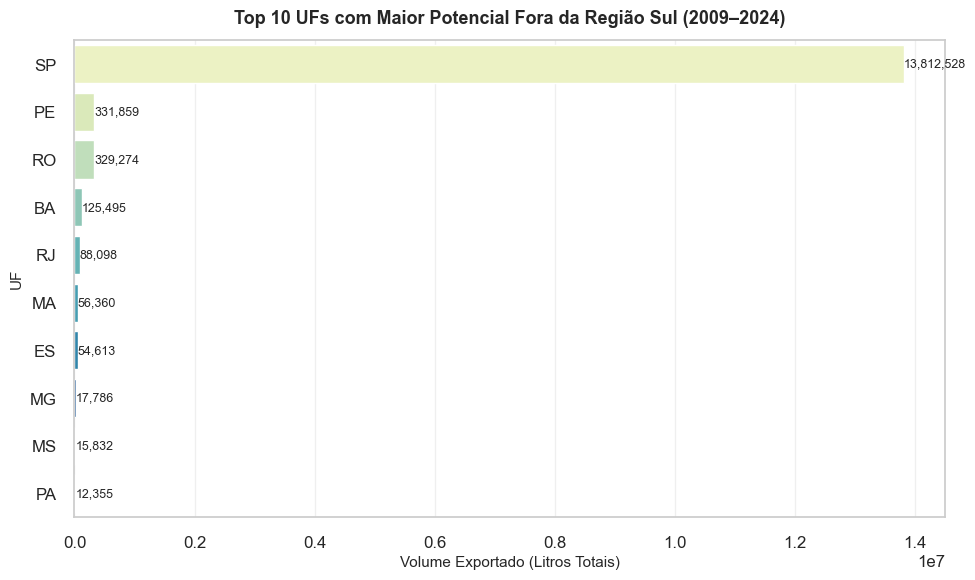

TOP 10 UFs por POTENCIAL (Volume Total em Litros) — EXCLUINDO SUL:


,UF_SIGLA,Total_Litros
0,SP,13812528.0
1,PE,331859.0
2,RO,329274.0
3,BA,125495.0
4,RJ,88098.0
5,MA,56360.0
6,ES,54613.0
7,MG,17786.0
8,MS,15832.0
9,PA,12355.0


In [ ]:
# UFs com maior potencial fora do Sul
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings

# Ignorar avisos de depreciação (opcional)
warnings.filterwarnings("ignore", category=FutureWarning)

# Tema visual moderno
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

# Função compatível (usa hue automaticamente e remove legenda redundante)
def safe_barplot(data, x, y, palette='YlGnBu', **kwargs):
    return sns.barplot(
        data=data,
        x=x,
        y=y,
        hue=y,
        palette=palette,
        legend=False,
        **kwargs
    )

# -- Preparar dados (reuso do gdf_proj) ---
ufs_sul = {'RS', 'SC', 'PR'}

# Garantir que colunas existam
assert 'UF_SIGLA' in gdf_proj.columns and 'Total_Litros' in gdf_proj.columns, \
    "gdf_proj precisa conter 'UF_SIGLA' e 'Total_Litros'."

# Filtrar apenas UFs fora do Sul e com dados válidos
df_no_sul = (
    gdf_proj.loc[~gdf_proj['UF_SIGLA'].isin(ufs_sul), ['UF_SIGLA', 'Total_Litros']]
    .dropna()
    .sort_values('Total_Litros', ascending=False)
)

# Selecionar top 10
top10_no_sul = df_no_sul.head(10).copy()

# --- Gráfico ---
plt.figure(figsize=(10, 6))
safe_barplot(
    data=top10_no_sul,
    x='Total_Litros',
    y='UF_SIGLA',
    palette='YlGnBu'
)

plt.title('Top 10 UFs com Maior Potencial Fora da Região Sul (2009–2024)',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Volume Exportado (Litros Totais)', fontsize=11)
plt.ylabel('UF', fontsize=11)
plt.grid(axis='x', alpha=0.3)

# Adicionar valores nas barras
for i, v in enumerate(top10_no_sul['Total_Litros']):
    plt.text(v, i, f'{v:,.0f}', va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

# --- Exibir ranking textual ---
print("TOP 10 UFs por POTENCIAL (Volume Total em Litros) — EXCLUINDO SUL:")
display(top10_no_sul.reset_index(drop=True))
